# "You Snooze, You Win" Challenge

Every year, the [PhysioNet/CinC (Computing in Cardiology) Challenge](https://www.physionet.org/challenge/) invites "participants to tackle clinically interesting problems that are either unsolved or not well-solved." For this year's week 2 machine learning challenge, BWSI has revived a past PhysioNet challenge based on sleep classification.

This year's challenge focuses on the classification of nonarousal and arousal timeframes. If you would like to understand the biological implications of the challenge, we recommend reading PhysioNet's [introduction](https://physionet.org/challenge/2018/) of the challenge.

For this challenge, you will classify samples into 5 classes (Arousal, NREM1, NREM2, NREM3, REM). Each sample consists of seven physiological signals (O2-M1, E1-M2, Chin1-Chin2, ABD, CHEST, AIRFLOW, ECG) measured at 200 Hz over a 60 second period (12000 timepoints). In this notebook, we provide code to import the data, visualize sample signals, implement an example classifier, and 'score' your model.

In [ ]:
### Import libraries ###

from google.colab import files
import matplotlib.pyplot as plt
import matplotlib

#set default plotting fonts
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 20}

matplotlib.rc('font', **font)

import numpy as np
import os
import pandas as pd
import random
from sklearn import metrics
from sklearn.utils import shuffle
import tensorflow as tf

## Loading the Dataset

This dataset is a modified version of the PhysioNet/CinC Challenge data, which were contributed by the Massachusetts General Hospital’s Computational Clinical Neurophysiology Laboratory, and the Clinical Data Animation Laboratory.
***
**Class labels:**
- 0 = Arousal
- 1 = NREM1
- 2 = NREM2
- 3 = NREM3
- 4 = REM
***
**Class descriptions:**

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/sleepStagesTable.svg?raw=true">

***
**Physiological signal description:**

O2-M1 - posterior brain activity (electroencephalography)

E1-M2 - left eye activity (electrooculography)

Chin1-Chin2 - chin movement (electromyography)

ABD - abdominal movement (electromyography)

CHEST - chest movement (electromyography)

AIRFLOW - respiratory airflow

ECG - cardiac activity (electrocardiography)
***
Run both cell blocks to get the challenge data.

In [ ]:
# # Clone repo and move into data directory (only run this once)
# !git clone https://github.com/BeaverWorksMedlytics2020/Data_Public
# os.chdir('./Data_Public/ChallengeProjects/Week2/')

### Locate or download the dataset ###

repo_path = "/content/Data_Public"
project_path = "/content/Data_Public/ChallengeProjects/Week2"

if not os.path.exists(repo_path):
    print("Downloading the dataset...")
    !git clone https://github.com/BeaverWorksMedlytics2020/Data_Public /content/Data_Public
else:
    print("Dataset folder already exists.")

os.chdir(project_path)

print("Current directory:", os.getcwd())

Cloning into '/content/Data_Public'...
remote: Enumerating objects: 5338, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 5338 (delta 28), reused 43 (delta 14), pack-reused 5274 (from 1)
Receiving objects: 100% (5338/5338), 1.11 GiB | 40.90 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Updating files: 100% (5134/5134), done.
Current directory: /content/Data_Public/ChallengeProjects/Week2


## Loading Data in Memory
Run the cell below to extract the raw training and test data. It may take a minute or two to run through. Here are the variables containing the data you will get:

* **data_train**: np array shape (4000, 12000, 7). Contains 4000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **labels_train**: np array shape (4000,). Contains ground truth labels for data_train. The order of the labels corresponds to the order of the training data.
* **ID_train**: list of 4000 unique IDs. The order of the IDs corresponds to the order of the training data.
* **data_test**: np array shape (1000, 12000, 7). Contains 1000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **ID_test**: list of 1000 unique IDs. The order of the IDs corresponds to the order of the training data.

We encourage you to print each of these variables to see what they look like.

In [ ]:
### Run once to import data ###

def get_file_locs():
    '''
    find all files in 'training' and 'test' directories and put their names
    under 'training' and 'test' keys in the file_dict dictionary
    '''

    file_dict = {'training':[], 'test':[]}
    for data_type in file_dict:
        for file in os.listdir('./' + data_type):
            file_dict[data_type].append(data_type + '/' + file)

    return file_dict

def get_sample_data(data_type, id_number):
    '''
    get signal data, label, and filename associated with given data type and index num

    parameters:

     data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

     id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    returns:

     sample_data -- dataframe with 1 row and 2 columns-- column "Signal" contains a series object
                    and column "Label" contains numeric label for that sample
    '''
    file = './' + data_type + '/' + str(id_number) + '.xz'

    #sample_data is a dataframe with 1 row and 2 columns--
    #"Signal" (contains a series object) and "Label" (contains numeric label)
    sample_data = pd.read_pickle('./' + file)

    return sample_data, file.split('/')[2]

file_dict = get_file_locs()
print(f"{len(file_dict['training'])} training samples found, {len(file_dict['test'])} test samples found")

data_train = np.zeros((4000, 12000, 7), dtype=np.float32)
labels_train = np.zeros(4000, dtype=np.int64)
ID_train = []

for i in range(4000):
    sample_data, ID = get_sample_data("training", i)

    data_train[i] = np.array(
        list(sample_data["Signal"]),
        dtype=np.float32
    ).reshape(12000, 7)

    labels_train[i] = int(sample_data["Label"].iloc[0])
    ID_train.append(ID)

    if i % 500 == 0:
        print("Loading training sample " + str(i))

data_test = np.zeros((1000, 12000, 7), dtype=np.float32)
ID_test = []

for i in range(1000):
    sample_data, ID = get_sample_data("test", i)

    data_test[i] = np.array(
        list(sample_data["Signal"]),
        dtype=np.float32
    ).reshape(12000, 7)

    ID_test.append(ID)

    if i % 500 == 0:
        print("Loading test sample " + str(i))

#keep original copy of data_train, labels_train, ID_train, data_test, and ID_test
# (for plotting or reference in case variables are shuffled later on)
data_train_orig = data_train.copy()
labels_train_orig = labels_train.copy()
ID_train_orig = ID_train.copy()
data_test_orig = data_test.copy()
ID_test_orig = ID_test.copy()

4000 training samples found, 1000 test samples found
Loading training sample 0
Loading training sample 500
Loading training sample 1000
Loading training sample 1500
Loading training sample 2000
Loading training sample 2500
Loading training sample 3000
Loading training sample 3500
Loading test sample 0
Loading test sample 500


## Data Visualization

Run the cell below to visualize the raw data for a single 60s sample for all 7 signals. We strongly urge you to visualize a few different samples to get a feel for how the data looks and how much each signal can vary in amplitude and frequency from sample to sample. You can change which sample is being visualized by changing the arguments to the graph_signals call.

Training 3274 (REM)


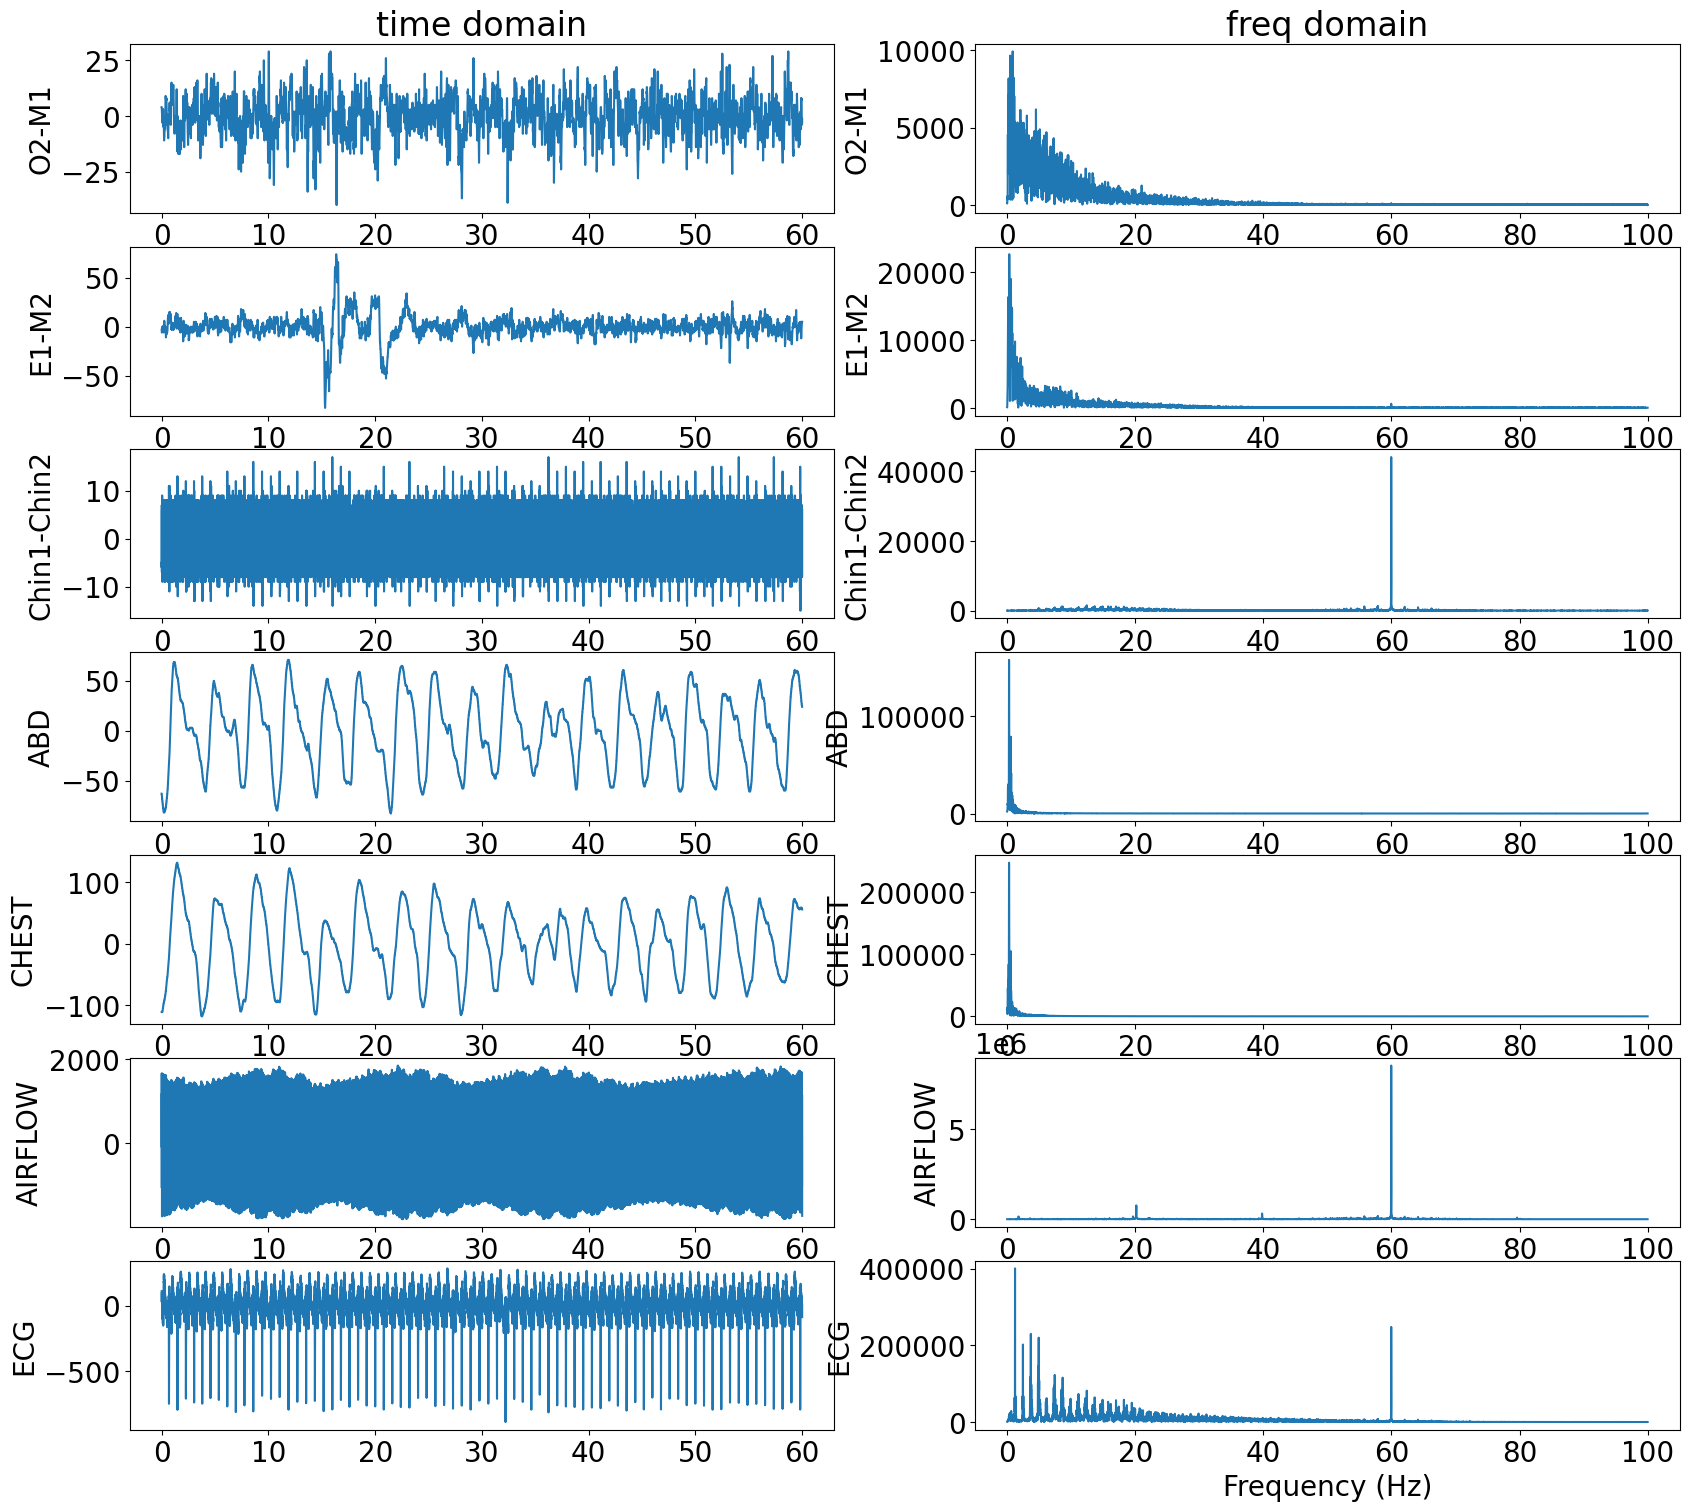

In [ ]:
### Define some useful functions to retrieve and plot data from individual samples ###

""" Initalize key reference dictionaries """
sig_dict = {0:'O2-M1', 1:'E1-M2', 2:'Chin1-Chin2', 3:'ABD', 4:'CHEST', 5:'AIRFLOW', 6:'ECG'}
sig_type_dict = {0:'Time (s)', 1:'Frequency (Hz)'}
stage_dict = {0:'Arousal', 1:'NREM1', 2:'NREM2', 3:'NREM3', 4:'REM'}

def graph_signals(data_type = 'training', id_number = None):
    '''
    Create a graph of multiple signals, with rows representing signal class, and
    columns representing signal domain (i.e. time or frequency)

    inputs:

      parameters:

      data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

      id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    '''

    assert data_type in ['test','training'], 'data_type should be either "test" or "training"'

    if id_number is None:
      if data_type == 'training':
        id_number = random.randint(0,3999)
      else:
        id_number = random.randint(0,999)

    #set time_signal_y based on 'test' or 'training' input
    if data_type == 'training':
        time_signal_y = data_train_orig[id_number,:,:]
    else:
        time_signal_y = data_test_orig[id_number,:,:]

    #Get signal values in time domain from either data_train_orig, or data_test_orig
    time_signal_x = np.arange(0, 60, step = 1/200) #this time axis doesn't change

    #Use time-domain signals to get frequency domain signals
    num_datapoints = time_signal_x.shape[0]
    freq_signal_x = np.arange(num_datapoints//2 + 1)/60
    freq_signal_y = np.ndarray(shape = (num_datapoints//2 + 1, 7))
    freq_signal_y = np.abs(np.fft.rfft(time_signal_y, axis = 0))

    plt.figure(figsize = (20, 18))
    title_list = ['time domain', 'freq domain']
    for signal_index in range(7): #7 classes of signal (O2-M1, E2-M2, etc.)
        for signal_domain_index in range(2): #2 types of signal (time and freq domain)
            plt.subplot(7, 2, 2*signal_index + signal_domain_index + 1)
            if signal_index==0:
                plt.title(title_list[signal_domain_index])
            if signal_domain_index == 0: #plot time domain signal
                plt.plot(time_signal_x, time_signal_y[:,signal_index])
            if signal_domain_index == 1: #plot freq domain signal
                plt.plot(freq_signal_x, freq_signal_y[:,signal_index])
            plt.ylabel(sig_dict[signal_index])
        plt.xlabel(sig_type_dict[signal_domain_index])
    plt.show()

# We can now use the above functions to retrieve data for a single sample
# (in the test or training set) and then plot it

#change these 2 lines to plot different samples (note that test set only has 1000 samples)
data_type = 'training'
id_number = random.randint(0,3999)

#print signal ID and the sample label (if known)
if data_type == "training":
    actual_label = int(labels_train_orig[id_number])
    print(
        data_type.title(),
        str(id_number),
        "(" + stage_dict[actual_label] + ")"
    )
else:
    print(data_type.title(), str(id_number), "(Unknown)")

#plot data from this sample
graph_signals(data_type = data_type, id_number = id_number)

## Example Classifier

Below is an example of a mediocre classifier for this dataset. It is a simple neural network that uses the spectral flatness of all signal classes its input features--that is, it has 7 input features.

While the example classifier makes use of a neural network, we encourage you to utilize any ML algorithm that you feel would be appropriate.

In [ ]:
### Define functions that calculate the features of a single sample ###

# import scipy.stats.mstats as mstats

# #I'm going to use spectral_flatness of the fft as a feature that could be used

# def spectral_flatness(fft, zero_thresh = None):
#   N = len(fft)
#   magnitude = abs(fft[:N//2])* 2 / N

#   if(zero_thresh is not None):
#       magnitude[magnitude < zero_thresh] = zero_thresh

#   if(any(magnitude<zero_thresh)):
#     raise ValueError("THis shouldn't happen")

#   sf = mstats.gmean(magnitude) / np.mean(magnitude)

#   return sf

# def get_features_for_single_sample(data_type = 'training', id_number = None):
#     '''
#     Calculate some number feature values for a single sample

#     parameters:

#       data_type -- Dictates whether sample comes from training set or test set.
#                  This input must be either 'training' or 'test' (defaults to 'training')

#       id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
#                  or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

#     returns:

#       feature_vector -- 1d array containing all feature values for this sample
#     '''

#     assert data_type in ['test','training'], 'data_type should be either "test" or "training"'

#     if id_number is None:
#         id_number=random.randint(0,999)

#     if data_type == 'training':
#         time_signal_y = data_train_orig[id_number,:,:]
#     else:
#         time_signal_y = data_test_orig[id_number,:,:]

#     #---Populate feature vector ---
#     #(Example uses spectral flatness, but you can populate feature_vector with
#     # anything that seems useful)

#     #get an fft for all signals in this sample
#     fft_arr = np.fft.rfft(time_signal_y, axis = 0)

#     #Initialize feature vector to zeros of right size
#     feature_vector = np.zeros((time_signal_y.shape[1],1))

#     #Enumerate over all classes of signal, calculate spectral flatness for each and append value to feature_vector
#     for ind in range(fft_arr.shape[1]): #for every class of signal
#         feature_vector[ind] = spectral_flatness(fft_arr[:,ind], zero_thresh = 10**-10) #calculate spectral flatness and add it to a feature vector

#     #---Finished populating feature vector---
#     #(now feature_vector is populated with hand-engineered features for this sample)

#     return feature_vector

# def get_features(data_type, num_samples):
#     '''
#     Retrieve features from num_samples samples in either test or training set,
#     return features for each sample and index of each sample

#     inputs:

#       data_type -- Dictates whether sample comes from training set or test set.
#                  This input must be either 'training' or 'test' (defaults to 'training')

#       num_samples -- For how many samples should features be calculated?
#                   (should not exceed total samples in a given data_type)

#     returns:

#       features -- n x p array of feature values for all samples where rows
#                   correspond to samples and columns correspond to feature number

#       order -- 1d array where index i contains the index of row i of the feature vector
#                (only needed if shuffling takes place later)
#     '''

#     features, order = np.array([]), np.array([])
#     for i in range(num_samples):
#         single_sample_features = get_features_for_single_sample(data_type = data_type, id_number = i)
#         features = np.hstack((features, single_sample_features)) if features.size else single_sample_features
#         order = np.append(order, i).astype(np.float64)

#     #ensure features are of type float32
#     features = features.astype(np.float64)

#     return np.transpose(features), order

### Physiological feature extraction ###

from scipy.signal import welch
from scipy.stats import skew, kurtosis

SAMPLING_RATE = 200

SIGNAL_NAMES = [
    "O2-M1",
    "E1-M2",
    "Chin1-Chin2",
    "ABD",
    "CHEST",
    "AIRFLOW",
    "ECG"
]

FREQUENCY_BANDS = {
    "very_low": (0.1, 0.5),
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "sigma": (12, 16),
    "beta": (16, 30),
    "high": (30, 45)
}


def calculate_band_power(frequencies, power_spectrum, low, high):
    """Calculate the power located within one frequency range."""

    band_mask = (frequencies >= low) & (frequencies < high)

    if not np.any(band_mask):
        return 0.0

    frequency_spacing = frequencies[1] - frequencies[0]

    return np.sum(power_spectrum[band_mask]) * frequency_spacing


def safe_correlation(first_signal, second_signal):
    """Calculate correlation without producing NaN for constant signals."""

    if np.std(first_signal) < 1e-10:
        return 0.0

    if np.std(second_signal) < 1e-10:
        return 0.0

    return np.corrcoef(first_signal, second_signal)[0, 1]


def extract_features_from_signal(signal_array, return_names=False):
    """
    Convert one 60-second, seven-channel recording into a feature vector.
    """

    signal_array = np.asarray(signal_array, dtype=np.float64)

    # Replace invalid values before calculating features
    signal_array = np.nan_to_num(
        signal_array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    feature_values = []
    feature_names = []

    for channel_index, signal_name in enumerate(SIGNAL_NAMES):

        channel = signal_array[:, channel_index]
        centered_channel = channel - np.median(channel)

        # ---------------------------------------------------------
        # Time-domain features
        # ---------------------------------------------------------

        time_features = {
            "mean": np.mean(channel),
            "std": np.std(channel),
            "median": np.median(channel),
            "iqr": (
                np.percentile(channel, 75)
                - np.percentile(channel, 25)
            ),
            "rms": np.sqrt(np.mean(channel ** 2)),
            "range": np.ptp(channel),
            "skewness": skew(channel, bias=False),
            "kurtosis": kurtosis(channel, fisher=True, bias=False),
            "zero_crossing_rate": np.mean(
                centered_channel[:-1] * centered_channel[1:] < 0
            ),
            "line_length": np.mean(np.abs(np.diff(channel)))
        }

        for feature_name, feature_value in time_features.items():
            feature_values.append(feature_value)
            feature_names.append(f"{signal_name}_{feature_name}")

        # ---------------------------------------------------------
        # Short-window activity features
        # Divide 60 seconds into six 10-second windows
        # ---------------------------------------------------------

        windows = channel.reshape(6, 2000)
        window_rms = np.sqrt(np.mean(windows ** 2, axis=1))
        window_std = np.std(windows, axis=1)

        window_features = {
            "maximum_window_rms": np.max(window_rms),
            "window_rms_variability": np.std(window_rms),
            "maximum_window_std": np.max(window_std),
            "window_std_variability": np.std(window_std)
        }

        for feature_name, feature_value in window_features.items():
            feature_values.append(feature_value)
            feature_names.append(f"{signal_name}_{feature_name}")

        # ---------------------------------------------------------
        # Frequency-domain features using Welch's method
        # ---------------------------------------------------------

        frequencies, power_spectrum = welch(
            channel,
            fs=SAMPLING_RATE,
            nperseg=1024
        )

        total_power = calculate_band_power(
            frequencies,
            power_spectrum,
            low=0.1,
            high=45
        )

        feature_values.append(np.log10(total_power + 1e-12))
        feature_names.append(f"{signal_name}_log_total_power")

        # Relative power in medically meaningful frequency ranges
        for band_name, (low, high) in FREQUENCY_BANDS.items():

            band_power = calculate_band_power(
                frequencies,
                power_spectrum,
                low,
                high
            )

            relative_band_power = band_power / (total_power + 1e-12)

            feature_values.append(relative_band_power)
            feature_names.append(
                f"{signal_name}_{band_name}_relative_power"
            )

        # Use frequencies between 0.1 and 45 Hz
        usable_mask = (frequencies >= 0.1) & (frequencies <= 45)
        usable_frequencies = frequencies[usable_mask]
        usable_power = power_spectrum[usable_mask]

        normalized_power = usable_power / (
            np.sum(usable_power) + 1e-12
        )

        spectral_entropy = -np.sum(
            normalized_power * np.log(normalized_power + 1e-12)
        ) / np.log(len(normalized_power))

        dominant_frequency = usable_frequencies[
            np.argmax(usable_power)
        ]

        spectral_flatness = (
            np.exp(np.mean(np.log(usable_power + 1e-12)))
            / (np.mean(usable_power) + 1e-12)
        )

        frequency_features = {
            "spectral_entropy": spectral_entropy,
            "dominant_frequency": dominant_frequency,
            "spectral_flatness": spectral_flatness
        }

        for feature_name, feature_value in frequency_features.items():
            feature_values.append(feature_value)
            feature_names.append(f"{signal_name}_{feature_name}")

    # -------------------------------------------------------------
    # Relationships between signals
    # -------------------------------------------------------------

    correlation_pairs = [
        (3, 4, "ABD_CHEST_correlation"),
        (3, 5, "ABD_AIRFLOW_correlation"),
        (4, 5, "CHEST_AIRFLOW_correlation"),
        (0, 1, "EEG_EOG_correlation"),
        (1, 2, "EOG_CHIN_correlation")
    ]

    for first_index, second_index, correlation_name in correlation_pairs:

        correlation = safe_correlation(
            signal_array[:, first_index],
            signal_array[:, second_index]
        )

        feature_values.append(correlation)
        feature_names.append(correlation_name)

    feature_values = np.asarray(feature_values, dtype=np.float32)

    # Final protection against invalid feature values
    feature_values = np.nan_to_num(
        feature_values,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if return_names:
        return feature_values, feature_names

    return feature_values


def get_features_for_single_sample(
    data_type="training",
    id_number=None
):
    """Extract features from one training or test sample."""

    assert data_type in ["training", "test"]

    if id_number is None:
        maximum_id = 3999 if data_type == "training" else 999
        id_number = random.randint(0, maximum_id)

    if data_type == "training":
        signal_array = data_train_orig[id_number]
    else:
        signal_array = data_test_orig[id_number]

    return extract_features_from_signal(signal_array)


def get_features(data_type, num_samples):
    """Extract features from several samples."""

    all_features = []

    for sample_number in range(num_samples):

        sample_features = get_features_for_single_sample(
            data_type=data_type,
            id_number=sample_number
        )

        all_features.append(sample_features)

        if sample_number % 500 == 0:
            print(
                f"Processed {data_type} sample "
                f"{sample_number}/{num_samples}"
            )

    features = np.vstack(all_features).astype(np.float32)
    order = np.arange(num_samples, dtype=np.int32)

    return features, order

In [ ]:
### Test the feature extractor on one recording ###

example_features, feature_names = extract_features_from_signal(
    data_train_orig[0],
    return_names=True
)

print("Number of features:", len(example_features))
print("Number of feature names:", len(feature_names))
print("All values are finite:", np.all(np.isfinite(example_features)))

print("\nFirst 15 features:")
for name, value in zip(feature_names[:15], example_features[:15]):
    print(f"{name}: {value:.5f}")

Number of features: 180
Number of feature names: 180
All values are finite: True

First 15 features:
O2-M1_mean: 0.01642
O2-M1_std: 13.81971
O2-M1_median: 0.00000
O2-M1_iqr: 18.00000
O2-M1_rms: 13.81972
O2-M1_range: 112.00000
O2-M1_skewness: 0.04922
O2-M1_kurtosis: 0.32826
O2-M1_zero_crossing_rate: 0.04925
O2-M1_line_length: 2.61630
O2-M1_maximum_window_rms: 14.72865
O2-M1_window_rms_variability: 1.35144
O2-M1_maximum_window_std: 14.71447
O2-M1_window_std_variability: 1.34659
O2-M1_log_total_power: 2.28896


In [ ]:
### Run every time you modify your feature extraction ###

print("Calculating features for 4,000 training samples...")

train_data, train_order = get_features(
    data_type="training",
    num_samples=4000
)

print("\nCalculating features for 1,000 challenge-test samples...")

test_data, test_order = get_features(
    data_type="test",
    num_samples=1000
)

print("\nFeature extraction complete.")
print("Training feature shape:", train_data.shape)
print("Challenge-test feature shape:", test_data.shape)

print(
    "All training features finite:",
    np.all(np.isfinite(train_data))
)

print(
    "All challenge-test features finite:",
    np.all(np.isfinite(test_data))
)

print(
    "Approximate training-feature memory:",
    f"{train_data.nbytes / 1_000_000:.2f} MB"
)

Calculating features for 4,000 training samples...
Processed training sample 0/4000
Processed training sample 500/4000
Processed training sample 1000/4000
Processed training sample 1500/4000
Processed training sample 2000/4000
Processed training sample 2500/4000
Processed training sample 3000/4000
Processed training sample 3500/4000

Calculating features for 1,000 challenge-test samples...
Processed test sample 0/1000
Processed test sample 500/1000

Feature extraction complete.
Training feature shape: (4000, 180)
Challenge-test feature shape: (1000, 180)
All training features finite: True
All challenge-test features finite: True
Approximate training-feature memory: 2.88 MB


## Visualize Entire Dataset's Features

In [ ]:
### Create labels using the actual labels loaded from the files ###

# Convert labels to integers from 0 through 4
integer_train_labels = labels_train_orig.astype(np.int64)

# Show how many samples belong to each class
class_counts = np.bincount(integer_train_labels, minlength=5)

print("Class distribution:")
for class_number, count in enumerate(class_counts):
    print(f"{class_number} - {stage_dict[class_number]}: {count}")

# Convert labels to one-hot format for the neural network
train_labels = tf.keras.utils.to_categorical(
    integer_train_labels,
    num_classes=5
).astype(np.float32)

print("\nInteger labels shape:", integer_train_labels.shape)
print("One-hot labels shape:", train_labels.shape)
print("First five integer labels:", integer_train_labels[:5])
print("First five one-hot labels:\n", train_labels[:5])

Class distribution:
0 - Arousal: 800
1 - NREM1: 800
2 - NREM2: 800
3 - NREM3: 800
4 - REM: 800

Integer labels shape: (4000,)
One-hot labels shape: (4000, 5)
First five integer labels: [0 0 0 0 0]
First five one-hot labels:
 [[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


In [ ]:
### Inspect patient information stored in the sample files ###

for sample_number in [0, 1, 799, 800, 1600, 2400, 3200]:
    sample, filename = get_sample_data(
        data_type="training",
        id_number=sample_number
    )

    print(
        f"Sample {sample_number}:",
        "index =", sample.index.tolist(),
        "| columns =", sample.columns.tolist()
    )

Sample 0: index = [0] | columns = ['Signal', 'Label']
Sample 1: index = [0] | columns = ['Signal', 'Label']
Sample 799: index = [0] | columns = ['Signal', 'Label']
Sample 800: index = [0] | columns = ['Signal', 'Label']
Sample 1600: index = [0] | columns = ['Signal', 'Label']
Sample 2400: index = [0] | columns = ['Signal', 'Label']
Sample 3200: index = [0] | columns = ['Signal', 'Label']


train_data.shape = (4000, 180) 
 train_labels.shape = (4000, 5)


train data:
 [[ 1.64166670e-02  1.38197136e+01  0.00000000e+00 ...  3.08571104e-02
  -3.23761046e-01 -2.12150197e-02]
 [-6.08333349e-02  1.20660458e+01  0.00000000e+00 ... -4.64123666e-01
  -3.93068254e-01 -8.52182601e-03]
 [ 1.08333332e-02  9.67016315e+00  0.00000000e+00 ... -3.98441374e-01
  -4.25493866e-01 -3.28758801e-03]
 ...
 [ 2.74166670e-02  5.90175104e+00  0.00000000e+00 ...  1.38707245e-02
  -6.12605274e-01 -9.75683623e-04]
 [ 2.05833334e-02  6.90924454e+00  0.00000000e+00 ...  1.74415186e-02
  -7.23742664e-01  5.66680729e-03]
 [-8.90833363e-02  5.34357691e+00  0.00000000e+00 ...  1.78079084e-02
  -7.69577861e-01 -3.33795534e-03]]

train labels:
 [[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


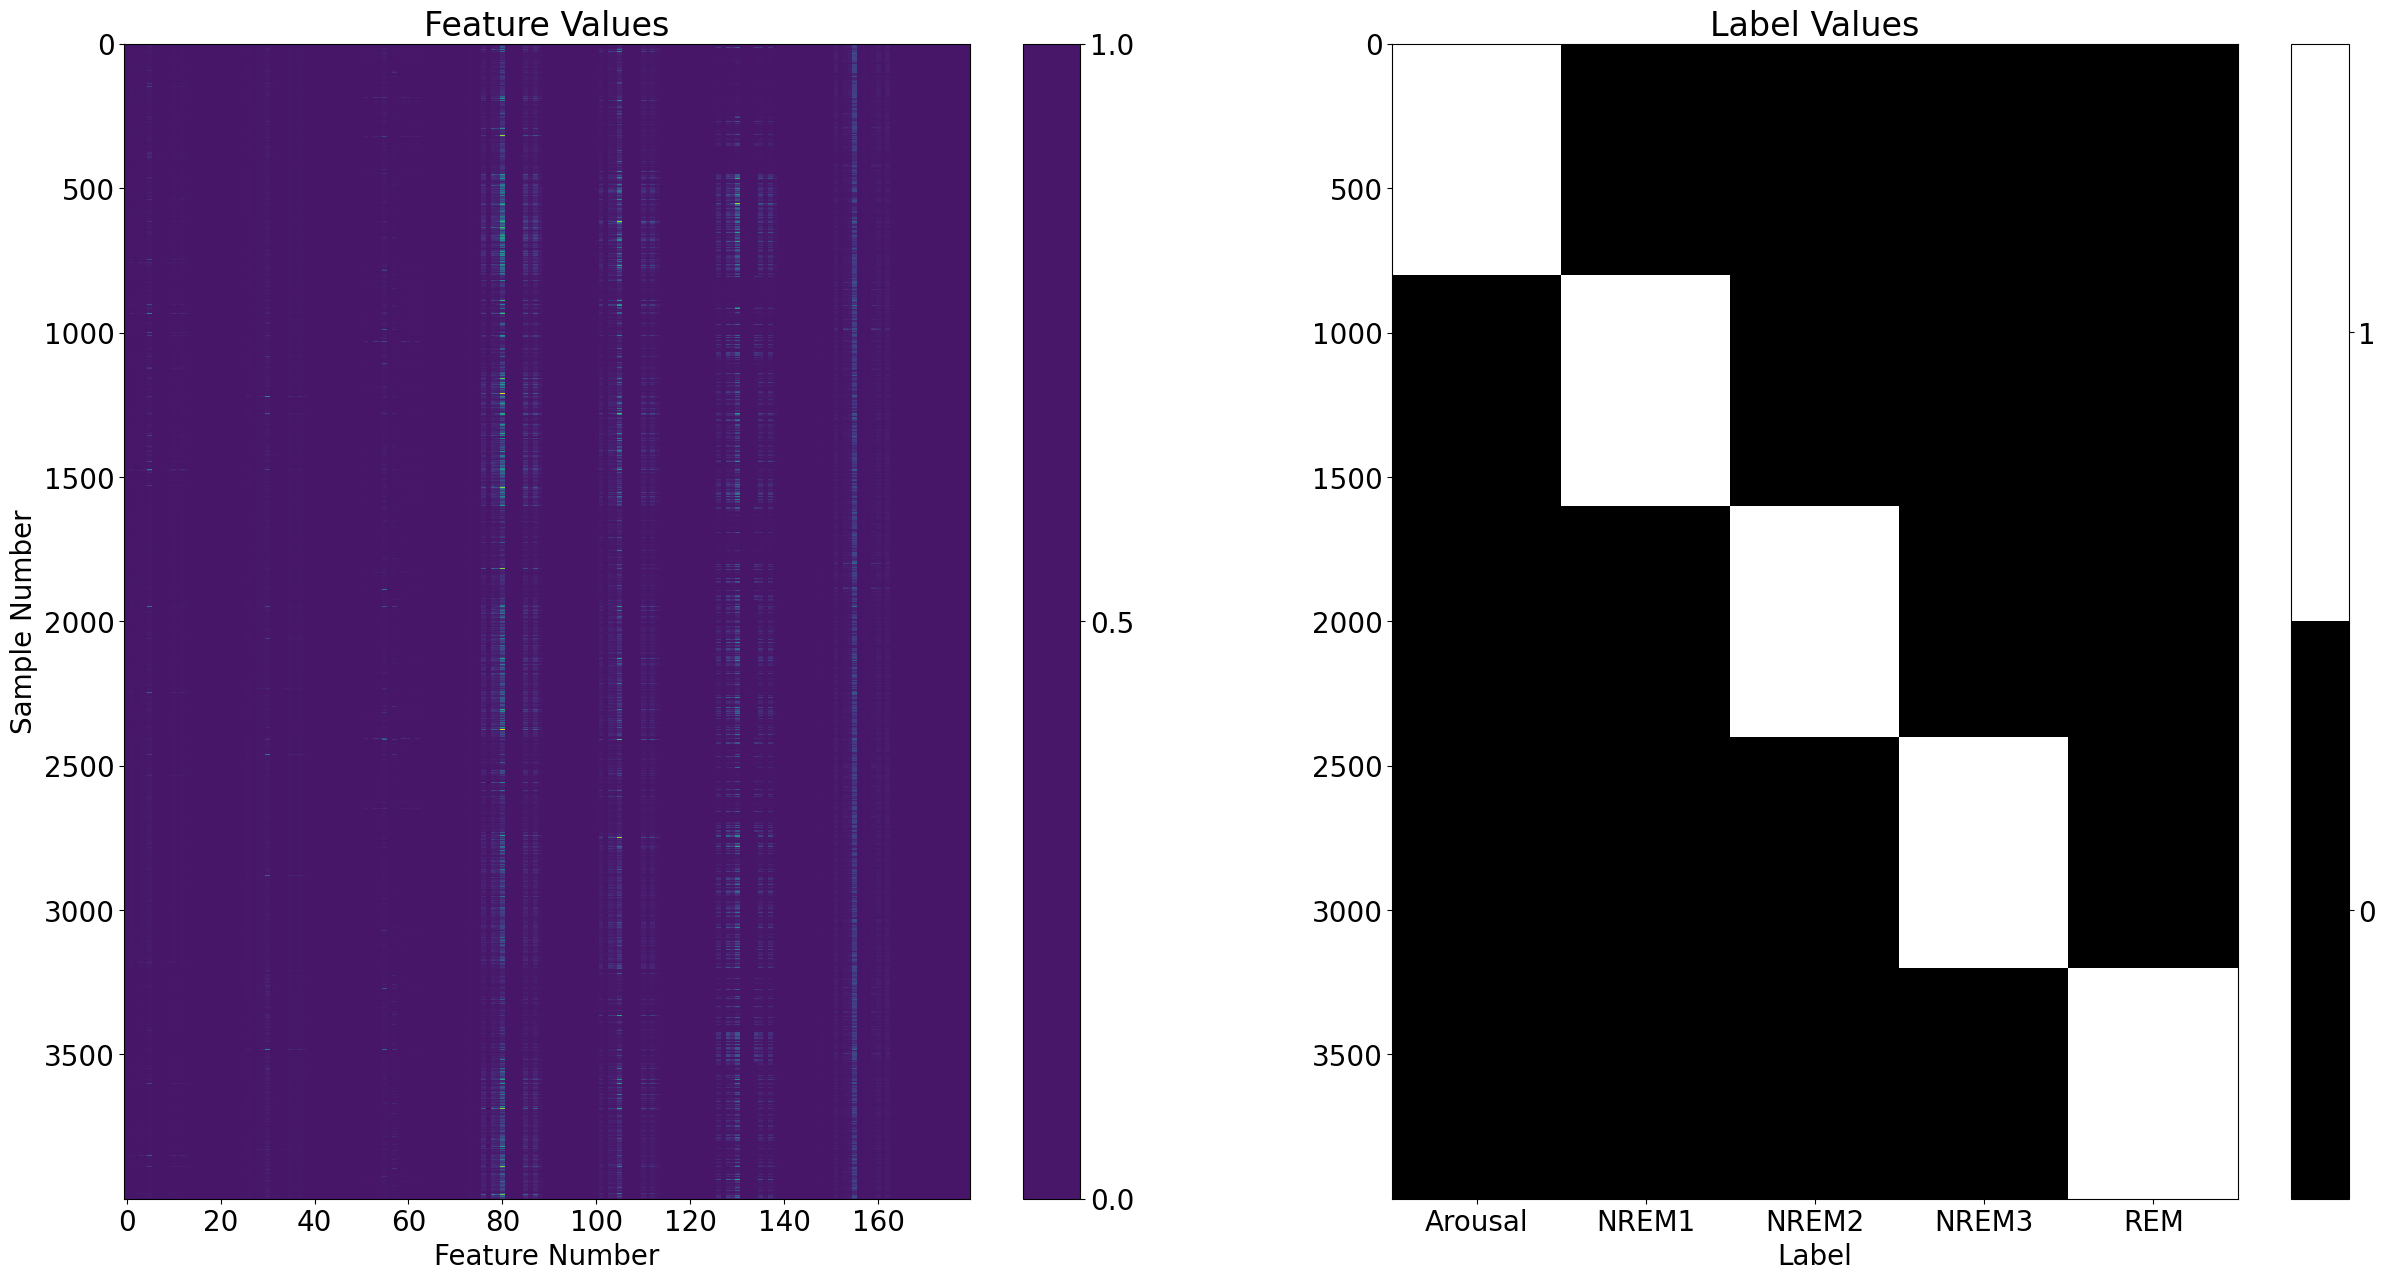

In [ ]:
### Run whenever you want to check or view your data and labels ###
print(f"train_data.shape = {train_data.shape} \n train_labels.shape = {train_labels.shape}\n\n")
print(f"train data:\n {train_data}\n\ntrain labels:\n {train_labels}")
#plot feature values and label values to show data clearly
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize= (30,15))

#Note: if your features are not scaled to the range 0->1 you might want to change vmin and vmax
featureImg = ax1.imshow(train_data[:,:], aspect = 'auto', interpolation = 'None')# vmin = 0, vmax = 1.0)
ax1.set_title('Feature Values')
ax1.set_ylabel('Sample Number')
ax1.set_xlabel('Feature Number')
fig.colorbar(featureImg, ax = ax1, boundaries = np.linspace(0.0, 1.0, 50), ticks = [0,0.5,1])

from matplotlib.colors import ListedColormap
bw_cmap = ListedColormap(np.array([[0,0,0,1],[1,1,1,1]])) # make a colormap manually
labelImg = ax2.imshow(train_labels, aspect = 'auto', cmap = bw_cmap,interpolation = 'None', vmin = 0, vmax = 1.0)
ax2.set_title('Label Values')
ax2.set_xlabel('Label')
ax2.set_xticks(range(len(stage_dict)))
ax2.set_xticklabels([stage_dict[i] for i in range(len(stage_dict))])
fig.colorbar(labelImg, ax = ax2, boundaries = np.linspace(-0.5, 1.5,3), ticks = [0, 1])

In [ ]:
#### Run every time you modify your feature extraction ###
#
# This cell splits up the labeled data into 3 subsets (training data, validation
# data, and test data)
#
# This 3-way split is very common in training a supervised learning model. The purpose of
# each partition is as follows:
#
# 1) Training data is used to adjust model weights (so-called model parameters)
# 2) Validation data is used to gauge how well model generalizes (allowing user
#    to compare between different trained models and/or non-trained model
#    parameters (hyperparameters))
# 3) Test data is used to provide an indicator of real-world performance (it
#    should not be used when deciding between models because this would result
#    in overfitting!)

# train_data_shuffled, train_labels_shuffled = shuffle(train_data, train_labels, random_state = 25)

# """ val_size (int) must be from 0-4000 """
# val_size = 1000
# mocktest_size = 500

# val_data = train_data_shuffled[:val_size]
# mocktest_data = train_data_shuffled[val_size:val_size + mocktest_size]
# partial_train_data = train_data_shuffled[val_size + mocktest_size:]

# val_labels = train_labels_shuffled[:val_size]
# mocktest_labels = train_labels_shuffled[val_size:val_size + mocktest_size]
# partial_train_labels = train_labels_shuffled[val_size + mocktest_size:]

# training_set = tf.data.Dataset.from_tensor_slices((partial_train_data, partial_train_labels))
# training_set = training_set.batch(40) #set batch size

### Create stratified training, validation, and mock-test sets ###

from sklearn.model_selection import train_test_split

# Create one index for every labeled sample
all_indices = np.arange(len(train_data))

# First split:
# 2500 samples for training and 1500 temporarily held aside
train_indices, temporary_indices = train_test_split(
    all_indices,
    test_size=1500,
    random_state=25,
    stratify=integer_train_labels
)

# Second split:
# Divide the 1500 held-aside samples into 1000 validation and 500 mock-test
val_indices, mocktest_indices = train_test_split(
    temporary_indices,
    test_size=500,
    random_state=25,
    stratify=integer_train_labels[temporary_indices]
)

# Feature arrays
partial_train_data = train_data[train_indices]
val_data = train_data[val_indices]
mocktest_data = train_data[mocktest_indices]

# Integer labels for traditional ML models
partial_train_integer_labels = integer_train_labels[train_indices]
val_integer_labels = integer_train_labels[val_indices]
mocktest_integer_labels = integer_train_labels[mocktest_indices]

# One-hot labels for neural networks
partial_train_labels = train_labels[train_indices]
val_labels = train_labels[val_indices]
mocktest_labels = train_labels[mocktest_indices]

# TensorFlow dataset for the neural-network option
training_set = tf.data.Dataset.from_tensor_slices(
    (partial_train_data, partial_train_labels)
)

training_set = (
    training_set
    .shuffle(
        buffer_size=len(partial_train_data),
        seed=25,
        reshuffle_each_iteration=True
    )
    .batch(40)
    .prefetch(tf.data.AUTOTUNE)
)

# Verify the split
print("Training shape:", partial_train_data.shape)
print("Validation shape:", val_data.shape)
print("Mock-test shape:", mocktest_data.shape)

print("\nTraining distribution:",
      np.bincount(partial_train_integer_labels, minlength=5))
print("Validation distribution:",
      np.bincount(val_integer_labels, minlength=5))
print("Mock-test distribution:",
      np.bincount(mocktest_integer_labels, minlength=5))


Training shape: (2500, 180)
Validation shape: (1000, 180)
Mock-test shape: (500, 180)

Training distribution: [500 500 500 500 500]
Validation distribution: [200 200 200 200 200]
Mock-test distribution: [100 100 100 100 100]


In [ ]:
### Train the first Extra Trees model ###

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
    roc_curve,
    auc
)

extra_trees_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=25,
    n_jobs=-1
)

print("Training Extra Trees...")

extra_trees_model.fit(
    partial_train_data,
    partial_train_integer_labels
)

print("Training complete.")

Training Extra Trees...
Training complete.


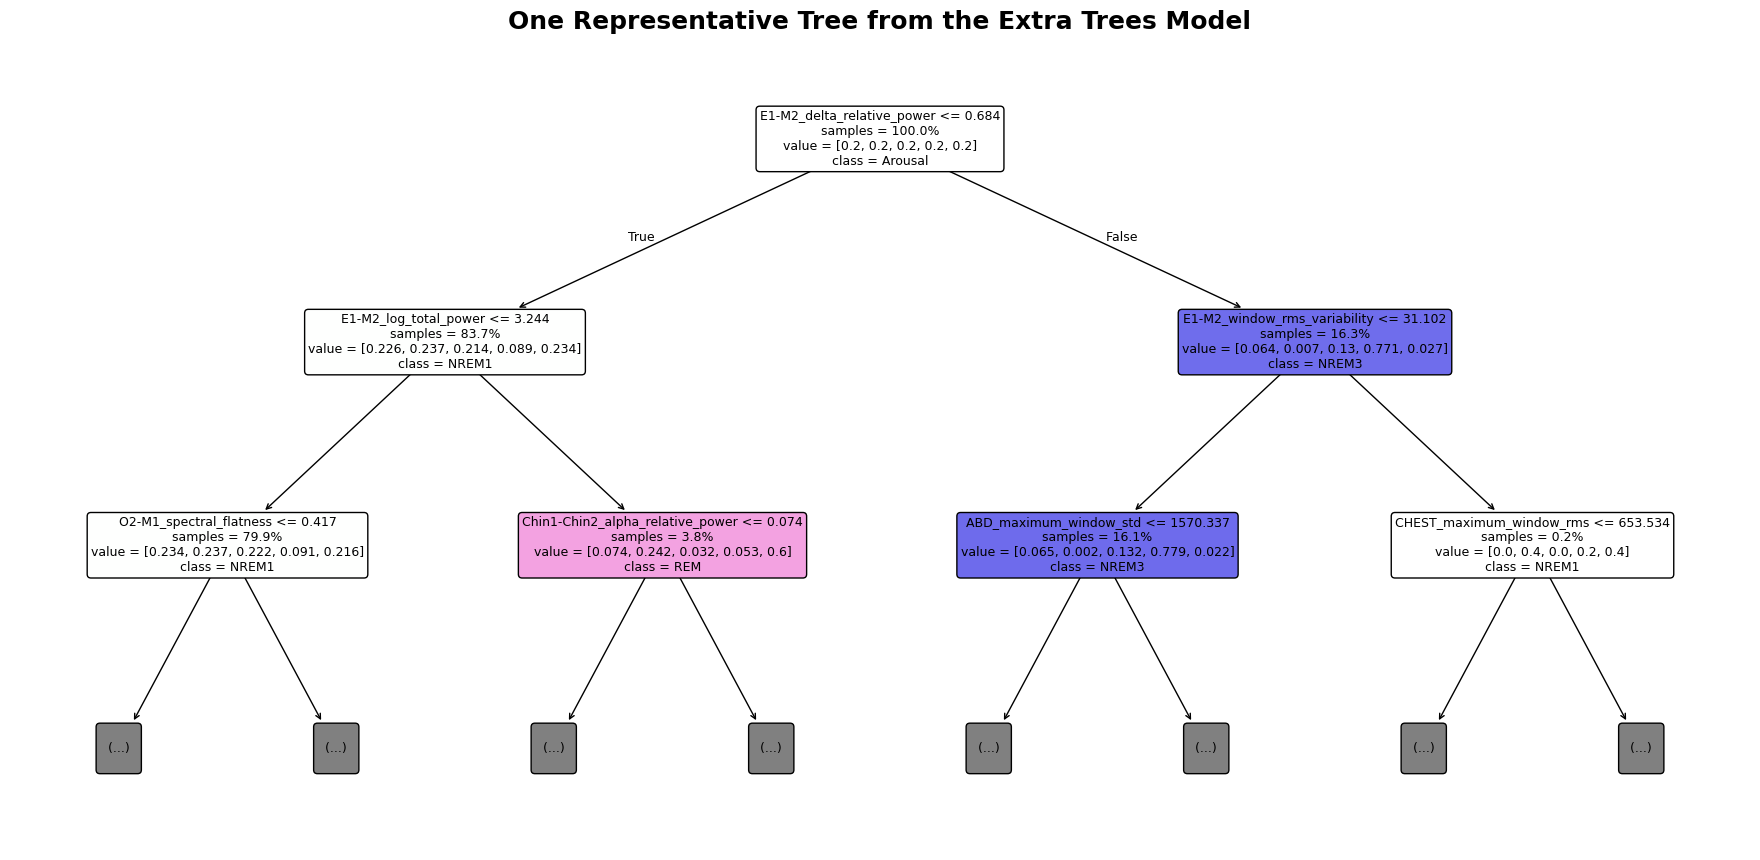

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

plot_tree(
    extra_trees_model.estimators_[0],  # Display one of the 500 trees
    feature_names=feature_names,
    class_names=[
        "Arousal",
        "NREM1",
        "NREM2",
        "NREM3",
        "REM"
    ],
    max_depth=2,       # Show only the first few levels
    filled=True,
    rounded=True,
    proportion=True,
    impurity=False,
    fontsize=9
)

plt.title(
    "One Representative Tree from the Extra Trees Model",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Validation accuracy:          0.7680
Validation balanced accuracy: 0.7680
Validation micro AUC:         0.9454
Validation arousal MCC:       0.7242

Classification report:
              precision    recall  f1-score   support

     Arousal     0.7535    0.8100    0.7807       200
       NREM1     0.6916    0.7400    0.7150       200
       NREM2     0.6798    0.6050    0.6402       200
       NREM3     0.8483    0.8950    0.8710       200
         REM     0.8681    0.7900    0.8272       200

    accuracy                         0.7680      1000
   macro avg     0.7683    0.7680    0.7668      1000
weighted avg     0.7683    0.7680    0.7668      1000



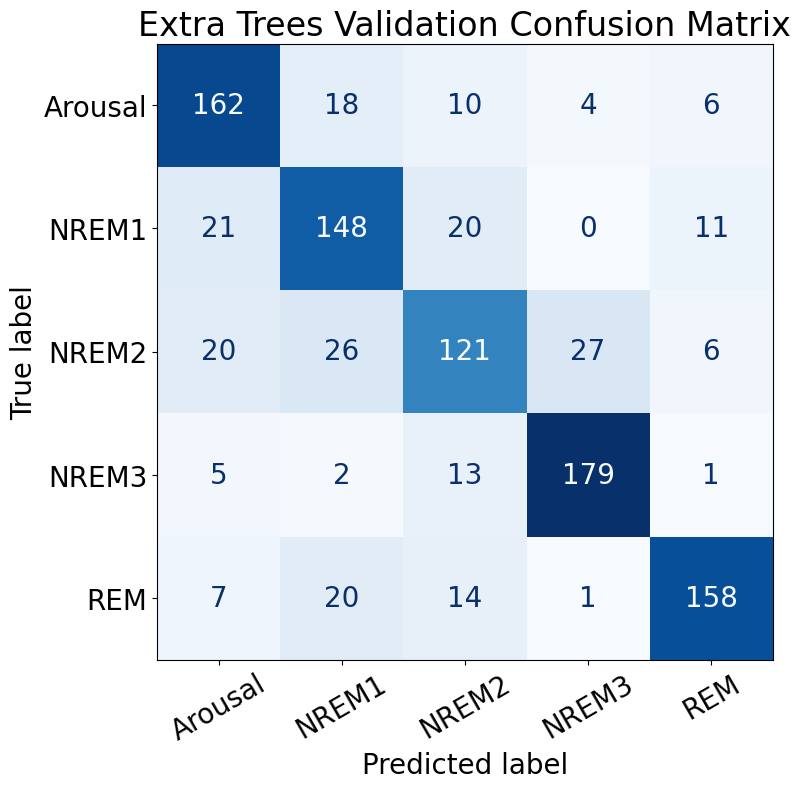

In [ ]:
### Evaluate Extra Trees on validation data ###

validation_probabilities = extra_trees_model.predict_proba(val_data)
validation_predictions = np.argmax(
    validation_probabilities,
    axis=1
)

# Standard accuracy
validation_accuracy = accuracy_score(
    val_integer_labels,
    validation_predictions
)

validation_balanced_accuracy = balanced_accuracy_score(
    val_integer_labels,
    validation_predictions
)

# Match the challenge's micro-average multiclass AUC calculation
validation_one_hot = np.eye(5)[val_integer_labels]

micro_fpr, micro_tpr, _ = roc_curve(
    validation_one_hot.ravel(),
    validation_probabilities.ravel()
)

validation_auc = auc(micro_fpr, micro_tpr)

# Match the challenge's Arousal versus Non-arousal MCC
true_arousal = (val_integer_labels == 0).astype(int)
predicted_arousal = (validation_predictions == 0).astype(int)

validation_mcc = matthews_corrcoef(
    true_arousal,
    predicted_arousal
)

print(f"Validation accuracy:          {validation_accuracy:.4f}")
print(f"Validation balanced accuracy: {validation_balanced_accuracy:.4f}")
print(f"Validation micro AUC:         {validation_auc:.4f}")
print(f"Validation arousal MCC:       {validation_mcc:.4f}")

print("\nClassification report:")
print(
    classification_report(
        val_integer_labels,
        validation_predictions,
        target_names=[
            stage_dict[i] for i in range(5)
        ],
        digits=4
    )
)

# Display the confusion matrix
confusion = confusion_matrix(
    val_integer_labels,
    validation_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        stage_dict[i] for i in range(5)
    ]
)

fig, ax = plt.subplots(figsize=(10, 8))
display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Extra Trees Validation Confusion Matrix")
plt.xticks(rotation=30)
plt.show()

Top 20 most important features:
                         Feature  Importance
      E1-M2_delta_relative_power    0.038699
      O2-M1_delta_relative_power    0.032281
   E1-M2_very_low_relative_power    0.023236
         O2-M1_spectral_flatness    0.020960
          O2-M1_spectral_entropy    0.020548
      O2-M1_alpha_relative_power    0.019632
       O2-M1_beta_relative_power    0.018056
           O2-M1_log_total_power    0.017840
          E1-M2_spectral_entropy    0.016084
         E1-M2_spectral_flatness    0.013685
Chin1-Chin2_sigma_relative_power    0.013187
      E1-M2_alpha_relative_power    0.012467
      O2-M1_sigma_relative_power    0.011970
                       E1-M2_iqr    0.011826
                       O2-M1_iqr    0.011730
 Chin1-Chin2_high_relative_power    0.011675
      E1-M2_theta_relative_power    0.011564
  Chin1-Chin2_zero_crossing_rate    0.011151
           E1-M2_log_total_power    0.010825
       O2-M1_high_relative_power    0.010495


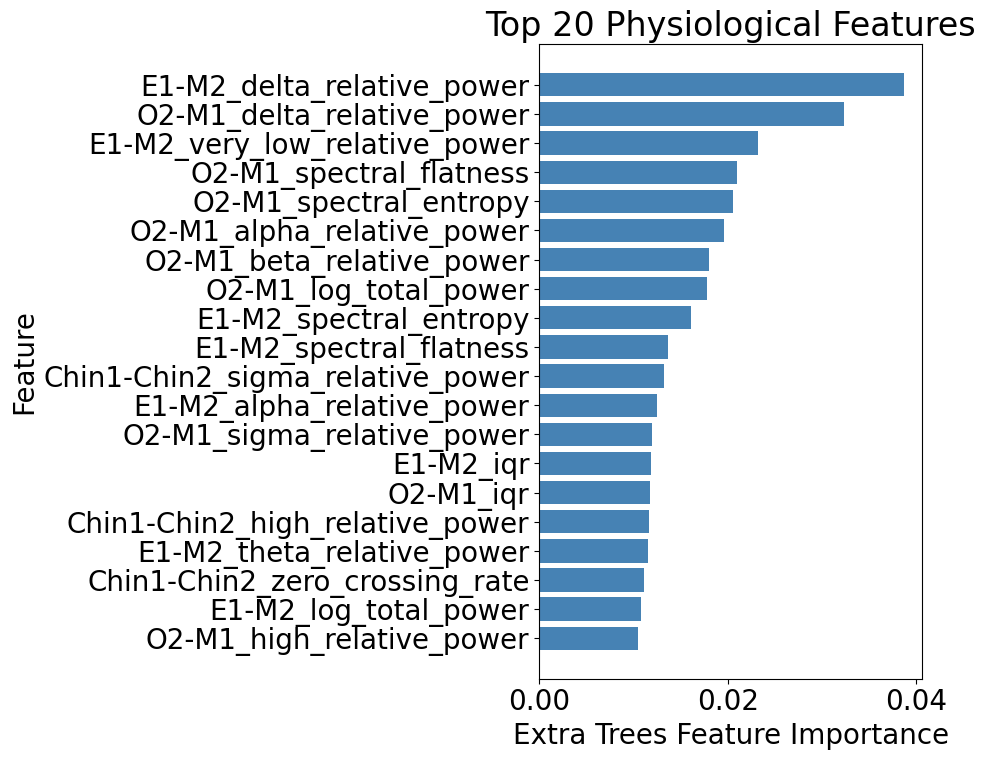

In [ ]:
### Display the most important Extra Trees features ###

if "feature_names" not in globals():
    _, feature_names = extract_features_from_signal(
        data_train_orig[0],
        return_names=True
    )

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": extra_trees_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 most important features:")
print(
    feature_importance_df.head(20).to_string(index=False)
)
plt.figure(figsize=(10, 8))

top_features = feature_importance_df.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="steelblue"
)

plt.xlabel("Extra Trees Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Physiological Features")
plt.tight_layout()
plt.show()

In [ ]:
### Train an RBF Support Vector Machine ###

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=3.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            cache_size=2000,
            random_state=25
        )
    )
])

print("Training RBF SVM...")

svm_model.fit(
    partial_train_data,
    partial_train_integer_labels
)

print("SVM training complete.")

Training RBF SVM...
SVM training complete.


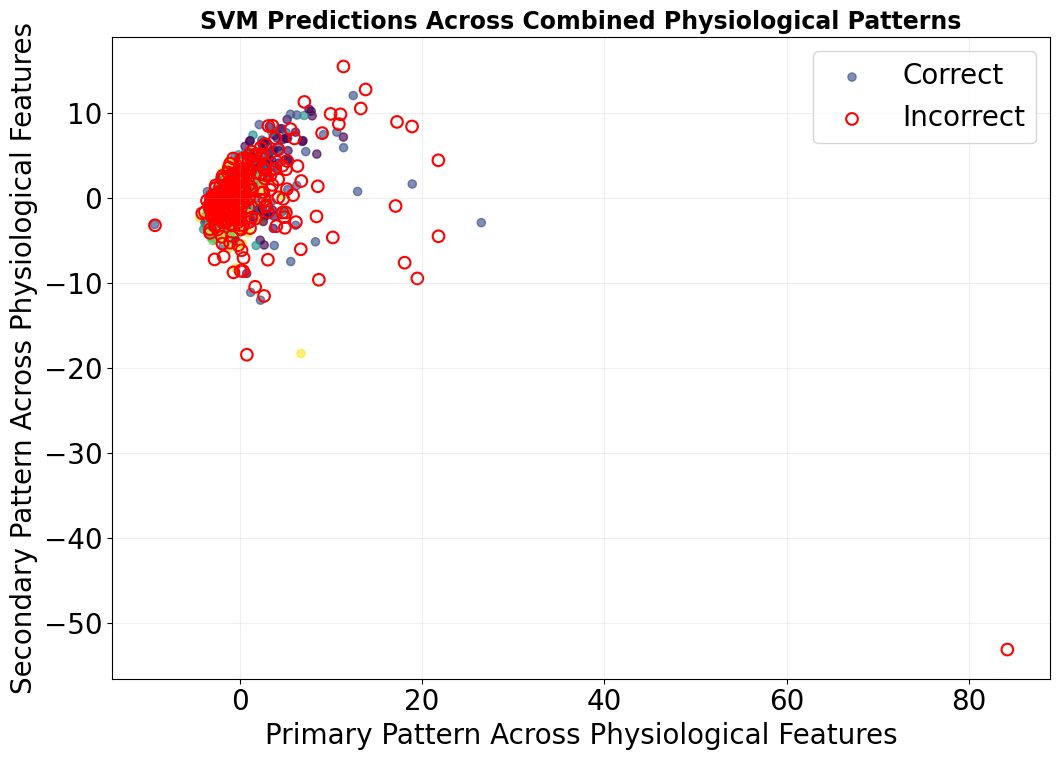

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize the validation features for visualization
visual_scaler = StandardScaler()
scaled_validation = visual_scaler.fit_transform(val_data)

# Reduce 180 features to two visual dimensions
pca = PCA(n_components=2, random_state=25)
validation_2d = pca.fit_transform(scaled_validation)

svm_correct = (
    svm_validation_predictions == val_integer_labels
)

plt.figure(figsize=(11, 8))

# Correct predictions
plt.scatter(
    validation_2d[svm_correct, 0],
    validation_2d[svm_correct, 1],
    c=val_integer_labels[svm_correct],
    cmap="viridis",
    alpha=0.65,
    s=35,
    label="Correct"
)

# Incorrect predictions
plt.scatter(
    validation_2d[~svm_correct, 0],
    validation_2d[~svm_correct, 1],
    facecolors="none",
    edgecolors="red",
    linewidths=1.5,
    s=70,
    label="Incorrect"
)

plt.xlabel("Primary Pattern Across Physiological Features")
plt.ylabel("Secondary Pattern Across Physiological Features")
plt.title(
    "SVM Predictions Across Combined Physiological Patterns",
    fontsize=17,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
### Evaluate the RBF SVM on validation data ###

svm_validation_probabilities = svm_model.predict_proba(val_data)
svm_validation_predictions = svm_model.predict(val_data)

# Accuracy
svm_accuracy = accuracy_score(
    val_integer_labels,
    svm_validation_predictions
)

svm_balanced_accuracy = balanced_accuracy_score(
    val_integer_labels,
    svm_validation_predictions
)

# Challenge-style micro AUC
svm_micro_fpr, svm_micro_tpr, _ = roc_curve(
    validation_one_hot.ravel(),
    svm_validation_probabilities.ravel()
)

svm_auc = auc(
    svm_micro_fpr,
    svm_micro_tpr
)

# Arousal versus Non-arousal MCC
svm_predicted_arousal = (
    svm_validation_predictions == 0
).astype(int)

svm_mcc = matthews_corrcoef(
    true_arousal,
    svm_predicted_arousal
)

print(f"SVM validation accuracy:          {svm_accuracy:.4f}")
print(f"SVM validation balanced accuracy: {svm_balanced_accuracy:.4f}")
print(f"SVM validation micro AUC:         {svm_auc:.4f}")
print(f"SVM validation arousal MCC:       {svm_mcc:.4f}")

print("\nSVM classification report:")
print(
    classification_report(
        val_integer_labels,
        svm_validation_predictions,
        target_names=[
            stage_dict[i] for i in range(5)
        ],
        digits=4
    )
)

# Compare the two models
comparison = pd.DataFrame({
    "Model": ["Extra Trees", "RBF SVM"],
    "Accuracy": [
        validation_accuracy,
        svm_accuracy
    ],
    "Micro AUC": [
        validation_auc,
        svm_auc
    ],
    "Arousal MCC": [
        validation_mcc,
        svm_mcc
    ]
})

print("\nModel comparison:")
print(comparison.to_string(index=False))

SVM validation accuracy:          0.7270
SVM validation balanced accuracy: 0.7270
SVM validation micro AUC:         0.9350
SVM validation arousal MCC:       0.6792

SVM classification report:
              precision    recall  f1-score   support

     Arousal     0.7176    0.7750    0.7452       200
       NREM1     0.6245    0.7150    0.6667       200
       NREM2     0.6441    0.5700    0.6048       200
       NREM3     0.8474    0.8050    0.8256       200
         REM     0.8191    0.7700    0.7938       200

    accuracy                         0.7270      1000
   macro avg     0.7305    0.7270    0.7272      1000
weighted avg     0.7305    0.7270    0.7272      1000


Model comparison:
      Model  Accuracy  Micro AUC  Arousal MCC
Extra Trees     0.768   0.945361     0.724157
    RBF SVM     0.727   0.934996     0.679199


In [ ]:
### Test probability ensembles of Extra Trees and SVM ###

ensemble_results = []

# Extra Trees weight ranges from 0% through 100%
for extra_trees_weight in np.linspace(0, 1, 21):

    svm_weight = 1 - extra_trees_weight

    blended_probabilities = (
        extra_trees_weight * validation_probabilities
        + svm_weight * svm_validation_probabilities
    )

    blended_predictions = np.argmax(
        blended_probabilities,
        axis=1
    )

    # Accuracy
    blended_accuracy = accuracy_score(
        val_integer_labels,
        blended_predictions
    )

    # Micro AUC
    blended_fpr, blended_tpr, _ = roc_curve(
        validation_one_hot.ravel(),
        blended_probabilities.ravel()
    )

    blended_auc = auc(
        blended_fpr,
        blended_tpr
    )

    # Arousal MCC
    blended_arousal_predictions = (
        blended_predictions == 0
    ).astype(int)

    blended_mcc = matthews_corrcoef(
        true_arousal,
        blended_arousal_predictions
    )

    ensemble_results.append({
        "Extra Trees Weight": extra_trees_weight,
        "SVM Weight": svm_weight,
        "Accuracy": blended_accuracy,
        "Micro AUC": blended_auc,
        "Arousal MCC": blended_mcc
    })

ensemble_results_df = pd.DataFrame(ensemble_results)

print("Best blend for accuracy:")
print(
    ensemble_results_df
    .sort_values("Accuracy", ascending=False)
    .head(5)
    .to_string(index=False)
)

print("\nBest blend for micro AUC:")
print(
    ensemble_results_df
    .sort_values("Micro AUC", ascending=False)
    .head(5)
    .to_string(index=False)
)

print("\nBest blend for arousal MCC:")
print(
    ensemble_results_df
    .sort_values("Arousal MCC", ascending=False)
    .head(5)
    .to_string(index=False)
)

Best blend for accuracy:
 Extra Trees Weight  SVM Weight  Accuracy  Micro AUC  Arousal MCC
               0.80        0.20     0.779   0.948453     0.741279
               0.75        0.25     0.774   0.948585     0.736328
               0.90        0.10     0.772   0.947536     0.736277
               0.85        0.15     0.771   0.948079     0.727800
               0.60        0.40     0.769   0.947913     0.735893

Best blend for micro AUC:
 Extra Trees Weight  SVM Weight  Accuracy  Micro AUC  Arousal MCC
               0.75        0.25     0.774   0.948585     0.736328
               0.70        0.30     0.768   0.948509     0.731543
               0.80        0.20     0.779   0.948453     0.741279
               0.65        0.35     0.765   0.948315     0.728185
               0.85        0.15     0.771   0.948079     0.727800

Best blend for arousal MCC:
 Extra Trees Weight  SVM Weight  Accuracy  Micro AUC  Arousal MCC
               0.80        0.20     0.779   0.948453     0.74

In [ ]:
### Train a hierarchical sleep-classification system ###

# Binary labels:
# 1 = Arousal
# 0 = Non-arousal
binary_train_labels = (
    partial_train_integer_labels == 0
).astype(int)

# Dedicated Arousal detector
arousal_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=25,
    n_jobs=-1
)

print("Training dedicated Arousal detector...")

arousal_model.fit(
    partial_train_data,
    binary_train_labels
)

# Select only Non-arousal training samples
non_arousal_train_mask = (
    partial_train_integer_labels != 0
)

sleep_stage_train_data = partial_train_data[
    non_arousal_train_mask
]

sleep_stage_train_labels = partial_train_integer_labels[
    non_arousal_train_mask
]

# Separate four-class model:
# NREM1, NREM2, NREM3, or REM
sleep_stage_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=26,
    n_jobs=-1
)

print("Training four-stage sleep classifier...")

sleep_stage_model.fit(
    sleep_stage_train_data,
    sleep_stage_train_labels
)

print("Hierarchical training complete.")

print(
    "Binary Arousal training distribution:",
    np.bincount(binary_train_labels)
)

print(
    "Four-stage training distribution:",
    np.bincount(sleep_stage_train_labels)[1:]
)

Training dedicated Arousal detector...
Training four-stage sleep classifier...
Hierarchical training complete.
Binary Arousal training distribution: [2000  500]
Four-stage training distribution: [500 500 500 500]


In [ ]:
### Evaluate the hierarchical model ###

# Probability that each validation sample is Arousal
arousal_probabilities = arousal_model.predict_proba(
    val_data
)[:, 1]

# Conditional probabilities for NREM1, NREM2, NREM3, and REM
conditional_sleep_probabilities = (
    sleep_stage_model.predict_proba(val_data)
)

# Create the final five-column probability array
hierarchical_probabilities = np.zeros(
    (len(val_data), 5),
    dtype=np.float64
)

# P(Arousal)
hierarchical_probabilities[:, 0] = arousal_probabilities

# P(stage) = P(Non-arousal) × P(stage | Non-arousal)
hierarchical_probabilities[:, 1:] = (
    (1 - arousal_probabilities)[:, None]
    * conditional_sleep_probabilities
)

# Confirm that every row adds to 1
print(
    "Probability row sums:",
    hierarchical_probabilities.sum(axis=1).min(),
    "to",
    hierarchical_probabilities.sum(axis=1).max()
)

hierarchical_predictions = np.argmax(
    hierarchical_probabilities,
    axis=1
)

# Accuracy
hierarchical_accuracy = accuracy_score(
    val_integer_labels,
    hierarchical_predictions
)

# Micro AUC
hierarchical_fpr, hierarchical_tpr, _ = roc_curve(
    validation_one_hot.ravel(),
    hierarchical_probabilities.ravel()
)

hierarchical_auc = auc(
    hierarchical_fpr,
    hierarchical_tpr
)

# Arousal MCC
hierarchical_predicted_arousal = (
    hierarchical_predictions == 0
).astype(int)

hierarchical_mcc = matthews_corrcoef(
    true_arousal,
    hierarchical_predicted_arousal
)

print(f"\nHierarchical accuracy:    {hierarchical_accuracy:.4f}")
print(f"Hierarchical micro AUC:   {hierarchical_auc:.4f}")
print(f"Hierarchical arousal MCC: {hierarchical_mcc:.4f}")

print("\nHierarchical classification report:")
print(
    classification_report(
        val_integer_labels,
        hierarchical_predictions,
        target_names=[
            stage_dict[i] for i in range(5)
        ],
        digits=4
    )
)

# Recreate our chosen 80/20 ensemble for comparison
best_ensemble_probabilities = (
    0.80 * validation_probabilities
    + 0.20 * svm_validation_probabilities
)

best_ensemble_predictions = np.argmax(
    best_ensemble_probabilities,
    axis=1
)

comparison = pd.DataFrame({
    "Model": [
        "Extra Trees",
        "RBF SVM",
        "80/20 Ensemble",
        "Hierarchical"
    ],
    "Accuracy": [
        validation_accuracy,
        svm_accuracy,
        accuracy_score(
            val_integer_labels,
            best_ensemble_predictions
        ),
        hierarchical_accuracy
    ],
    "Micro AUC": [
        validation_auc,
        svm_auc,
        0.948453,
        hierarchical_auc
    ],
    "Arousal MCC": [
        validation_mcc,
        svm_mcc,
        matthews_corrcoef(
            true_arousal,
            (best_ensemble_predictions == 0).astype(int)
        ),
        hierarchical_mcc
    ]
})

print("\nFull model comparison:")
print(comparison.to_string(index=False))

Probability row sums: 0.9999999999999996 to 1.0000000000000007

Hierarchical accuracy:    0.7540
Hierarchical micro AUC:   0.9452
Hierarchical arousal MCC: 0.7117

Hierarchical classification report:
              precision    recall  f1-score   support

     Arousal     0.6905    0.8700    0.7699       200
       NREM1     0.6891    0.6650    0.6768       200
       NREM2     0.6821    0.5900    0.6327       200
       NREM3     0.8551    0.8850    0.8698       200
         REM     0.8686    0.7600    0.8107       200

    accuracy                         0.7540      1000
   macro avg     0.7571    0.7540    0.7520      1000
weighted avg     0.7571    0.7540    0.7520      1000


Full model comparison:
         Model  Accuracy  Micro AUC  Arousal MCC
   Extra Trees     0.768   0.945361     0.724157
       RBF SVM     0.727   0.934996     0.679199
80/20 Ensemble     0.779   0.948453     0.741279
  Hierarchical     0.754   0.945214     0.711717


In [ ]:
### Save an engineered-feature recovery file ###

checkpoint_file = "/content/sleep_features_checkpoint.npz"

np.savez_compressed(
    checkpoint_file,
    train_data=train_data,
    test_data=test_data,
    labels_train_orig=labels_train_orig,
    train_indices=train_indices,
    val_indices=val_indices,
    mocktest_indices=mocktest_indices,
    feature_names=np.array(feature_names)
)

print(
    "Checkpoint created:",
    f"{os.path.getsize(checkpoint_file) / 1_000_000:.2f} MB"
)

files.download(checkpoint_file)

Checkpoint created: 3.14 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
### Extract short-window EEG sleep-spindle features ###

SPINDLE_FEATURE_NAMES = [
    "EEG_spindle_sigma_mean",
    "EEG_spindle_sigma_std",
    "EEG_spindle_sigma_max",
    "EEG_spindle_sigma_90th_percentile",
    "EEG_spindle_burst_fraction",
    "EEG_spindle_peak_to_median",
    "EEG_window_delta_mean",
    "EEG_window_theta_mean",
    "EEG_log_sigma_to_delta_ratio"
]


def extract_spindle_features(signal_array):
    """
    Extract possible sleep-spindle features from the O2-M1 EEG channel.

    The 60-second EEG signal is divided into thirty 2-second windows.
    """

    # O2-M1 is channel 0
    eeg = np.asarray(
        signal_array[:, 0],
        dtype=np.float64
    )

    eeg = np.nan_to_num(
        eeg,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # 12,000 measurements become 30 windows × 400 measurements
    eeg_windows = eeg.reshape(30, 400)

    # Remove the baseline separately from every window
    eeg_windows = (
        eeg_windows
        - np.mean(eeg_windows, axis=1, keepdims=True)
    )

    # Calculate a frequency spectrum for every 2-second window
    frequencies, window_power = welch(
        eeg_windows,
        fs=SAMPLING_RATE,
        nperseg=400,
        axis=1
    )

    frequency_spacing = frequencies[1] - frequencies[0]

    def window_band_power(low_frequency, high_frequency):
        band_mask = (
            (frequencies >= low_frequency)
            & (frequencies < high_frequency)
        )

        return (
            np.sum(window_power[:, band_mask], axis=1)
            * frequency_spacing
        )

    # Total EEG power used to calculate relative power
    total_window_power = window_band_power(0.5, 30)

    delta_power = window_band_power(0.5, 4)
    theta_power = window_band_power(4, 8)

    # Sleep-spindle frequency range
    sigma_power = window_band_power(11, 16)

    delta_relative = (
        delta_power / (total_window_power + 1e-12)
    )

    theta_relative = (
        theta_power / (total_window_power + 1e-12)
    )

    sigma_relative = (
        sigma_power / (total_window_power + 1e-12)
    )

    # Identify windows with unusually strong sigma activity
    sigma_median = np.median(sigma_relative)

    sigma_iqr = (
        np.percentile(sigma_relative, 75)
        - np.percentile(sigma_relative, 25)
    )

    spindle_threshold = (
        sigma_median + 1.5 * sigma_iqr
    )

    spindle_burst_fraction = np.mean(
        sigma_relative > spindle_threshold
    )

    spindle_features = np.array([
        np.mean(sigma_relative),
        np.std(sigma_relative),
        np.max(sigma_relative),
        np.percentile(sigma_relative, 90),
        spindle_burst_fraction,
        np.max(sigma_relative) / (sigma_median + 1e-12),
        np.mean(delta_relative),
        np.mean(theta_relative),
        np.mean(
            np.log1p(
                sigma_relative / (delta_relative + 1e-12)
            )
        )
    ], dtype=np.float32)

    return np.nan_to_num(
        spindle_features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


### Test on one training recording ###

example_spindle_features = extract_spindle_features(
    data_train_orig[0]
)

print(
    "Number of spindle features:",
    len(example_spindle_features)
)

print(
    "All spindle features finite:",
    np.all(np.isfinite(example_spindle_features))
)

for name, value in zip(
    SPINDLE_FEATURE_NAMES,
    example_spindle_features
):
    print(f"{name}: {value:.6f}")

Number of spindle features: 9
All spindle features finite: True
EEG_spindle_sigma_mean: 0.108715
EEG_spindle_sigma_std: 0.101213
EEG_spindle_sigma_max: 0.391769
EEG_spindle_sigma_90th_percentile: 0.252499
EEG_spindle_burst_fraction: 0.200000
EEG_spindle_peak_to_median: 5.212910
EEG_window_delta_mean: 0.592638
EEG_window_theta_mean: 0.148264
EEG_log_sigma_to_delta_ratio: 0.221289


In [ ]:
### Calculate spindle features for the complete dataset ###

def create_spindle_feature_matrix(
    raw_data,
    dataset_name
):
    number_of_samples = len(raw_data)

    spindle_matrix = np.zeros(
        (number_of_samples, 9),
        dtype=np.float32
    )

    for sample_number in range(number_of_samples):

        spindle_matrix[sample_number] = (
            extract_spindle_features(
                raw_data[sample_number]
            )
        )

        if sample_number % 500 == 0:
            print(
                f"Processed {dataset_name} spindle sample "
                f"{sample_number}/{number_of_samples}"
            )

    return spindle_matrix


print("Extracting training spindle features...")

train_spindle_features = create_spindle_feature_matrix(
    data_train_orig,
    dataset_name="training"
)

print("\nExtracting challenge-test spindle features...")

test_spindle_features = create_spindle_feature_matrix(
    data_test_orig,
    dataset_name="challenge-test"
)

# Add the nine new columns to the original 180 columns
train_data_with_spindles = np.hstack([
    train_data,
    train_spindle_features
]).astype(np.float32)

test_data_with_spindles = np.hstack([
    test_data,
    test_spindle_features
]).astype(np.float32)

feature_names_with_spindles = (
    list(feature_names)
    + SPINDLE_FEATURE_NAMES
)

print("\nOriginal training shape:", train_data.shape)
print(
    "Spindle-enhanced training shape:",
    train_data_with_spindles.shape
)

print("Original challenge-test shape:", test_data.shape)
print(
    "Spindle-enhanced challenge-test shape:",
    test_data_with_spindles.shape
)

print(
    "All enhanced training values finite:",
    np.all(np.isfinite(train_data_with_spindles))
)

print(
    "Feature-name count:",
    len(feature_names_with_spindles)
)

Extracting training spindle features...
Processed training spindle sample 0/4000
Processed training spindle sample 500/4000
Processed training spindle sample 1000/4000
Processed training spindle sample 1500/4000
Processed training spindle sample 2000/4000
Processed training spindle sample 2500/4000
Processed training spindle sample 3000/4000
Processed training spindle sample 3500/4000

Extracting challenge-test spindle features...
Processed challenge-test spindle sample 0/1000
Processed challenge-test spindle sample 500/1000

Original training shape: (4000, 180)
Spindle-enhanced training shape: (4000, 189)
Original challenge-test shape: (1000, 180)
Spindle-enhanced challenge-test shape: (1000, 189)
All enhanced training values finite: True
Feature-name count: 189


In [ ]:
### Use the exact same split with the 189-feature dataset ###

partial_train_data_spindles = (
    train_data_with_spindles[train_indices]
)

val_data_spindles = (
    train_data_with_spindles[val_indices]
)

mocktest_data_spindles = (
    train_data_with_spindles[mocktest_indices]
)

print(
    "Spindle training shape:",
    partial_train_data_spindles.shape
)

print(
    "Spindle validation shape:",
    val_data_spindles.shape
)

print(
    "Spindle mock-test shape:",
    mocktest_data_spindles.shape
)


### Train the enhanced model ###

spindle_extra_trees_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=25,
    n_jobs=-1
)

print("\nTraining spindle-enhanced Extra Trees...")

spindle_extra_trees_model.fit(
    partial_train_data_spindles,
    partial_train_integer_labels
)

print("Spindle-enhanced training complete.")

Spindle training shape: (2500, 189)
Spindle validation shape: (1000, 189)
Spindle mock-test shape: (500, 189)

Training spindle-enhanced Extra Trees...
Spindle-enhanced training complete.


In [ ]:
### Evaluate spindle-enhanced Extra Trees ###

from sklearn.metrics import recall_score

spindle_validation_probabilities = (
    spindle_extra_trees_model.predict_proba(
        val_data_spindles
    )
)

spindle_validation_predictions = np.argmax(
    spindle_validation_probabilities,
    axis=1
)

# Accuracy
spindle_accuracy = accuracy_score(
    val_integer_labels,
    spindle_validation_predictions
)

# Micro AUC
spindle_fpr, spindle_tpr, _ = roc_curve(
    validation_one_hot.ravel(),
    spindle_validation_probabilities.ravel()
)

spindle_auc = auc(
    spindle_fpr,
    spindle_tpr
)

# Arousal MCC
spindle_predicted_arousal = (
    spindle_validation_predictions == 0
).astype(int)

spindle_mcc = matthews_corrcoef(
    true_arousal,
    spindle_predicted_arousal
)

# Recall for every class
original_class_recalls = recall_score(
    val_integer_labels,
    validation_predictions,
    average=None
)

spindle_class_recalls = recall_score(
    val_integer_labels,
    spindle_validation_predictions,
    average=None
)

print(f"Spindle-model accuracy:    {spindle_accuracy:.4f}")
print(f"Spindle-model micro AUC:   {spindle_auc:.4f}")
print(f"Spindle-model arousal MCC: {spindle_mcc:.4f}")

print("\nSpindle-model classification report:")
print(
    classification_report(
        val_integer_labels,
        spindle_validation_predictions,
        target_names=[
            stage_dict[i] for i in range(5)
        ],
        digits=4
    )
)

feature_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Micro AUC",
        "Arousal MCC",
        "NREM2 Recall"
    ],
    "Original 180 Features": [
        validation_accuracy,
        validation_auc,
        validation_mcc,
        original_class_recalls[2]
    ],
    "With 9 Spindle Features": [
        spindle_accuracy,
        spindle_auc,
        spindle_mcc,
        spindle_class_recalls[2]
    ]
})

feature_comparison["Change"] = (
    feature_comparison["With 9 Spindle Features"]
    - feature_comparison["Original 180 Features"]
)

print("\nControlled feature comparison:")
print(feature_comparison.to_string(index=False))

Spindle-model accuracy:    0.7640
Spindle-model micro AUC:   0.9450
Spindle-model arousal MCC: 0.7243

Spindle-model classification report:
              precision    recall  f1-score   support

     Arousal     0.7619    0.8000    0.7805       200
       NREM1     0.6981    0.7400    0.7184       200
       NREM2     0.6573    0.5850    0.6190       200
       NREM3     0.8349    0.9100    0.8708       200
         REM     0.8626    0.7850    0.8220       200

    accuracy                         0.7640      1000
   macro avg     0.7630    0.7640    0.7622      1000
weighted avg     0.7630    0.7640    0.7622      1000


Controlled feature comparison:
      Metric  Original 180 Features  With 9 Spindle Features    Change
    Accuracy               0.768000                 0.764000 -0.004000
   Micro AUC               0.945361                 0.944964 -0.000397
 Arousal MCC               0.724157                 0.724267  0.000110
NREM2 Recall               0.605000                 0.5

In [ ]:
### Train an XGBoost multiclass model on the original 180 features ###

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_alpha=0.05,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=25,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    partial_train_data,
    partial_train_integer_labels
)

print("XGBoost training complete.")

Training XGBoost...
XGBoost training complete.


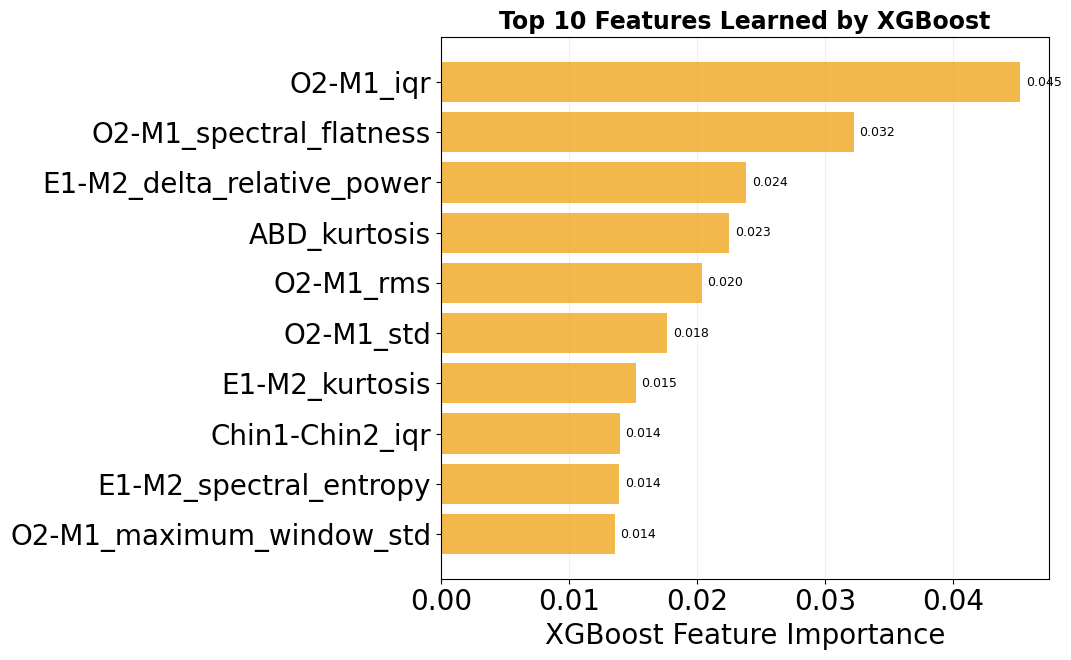

In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

top_10_xgb_features = (
    xgb_importance
    .sort_values("Importance", ascending=False)
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_10_xgb_features["Feature"],
    top_10_xgb_features["Importance"],
    color="#F2B84B"
)

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=4,
    fontsize=9
)

plt.xlabel("XGBoost Feature Importance")
plt.title(
    "Top 10 Features Learned by XGBoost",
    fontsize=17,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

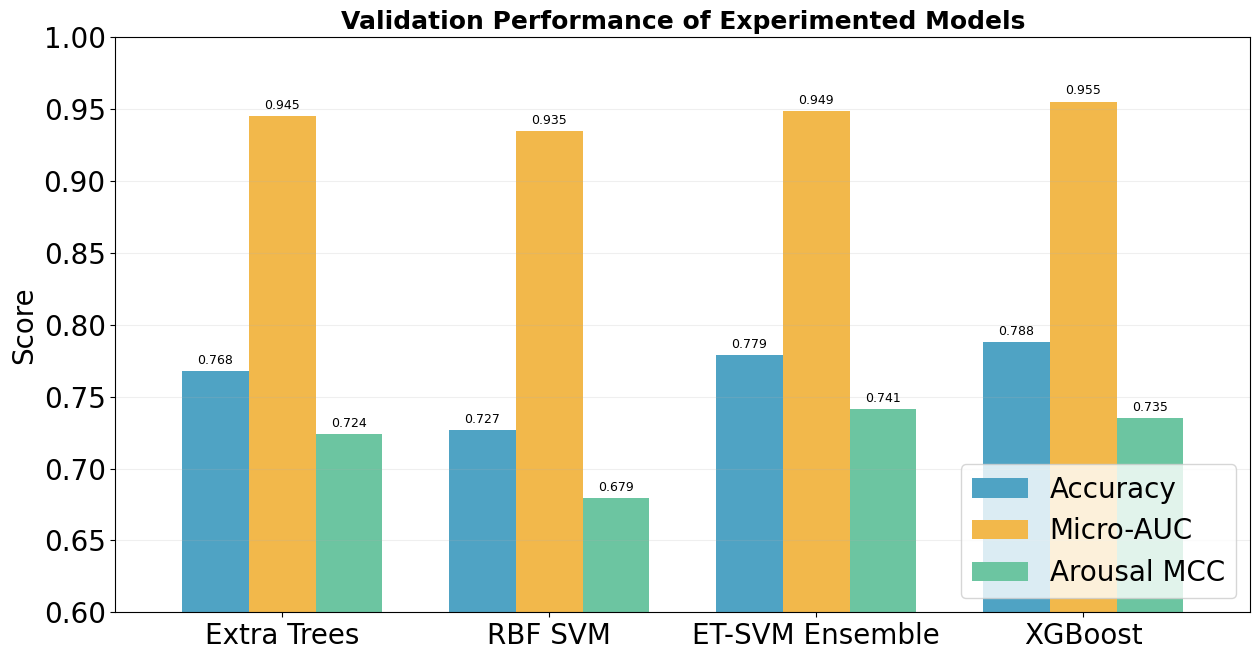

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Extra Trees",
        "RBF SVM",
        "ET-SVM Ensemble",
        "XGBoost"
    ],
    "Accuracy": [
        0.7680,
        0.7270,
        0.7790,
        0.7880
    ],
    "Micro-AUC": [
        0.9454,
        0.9350,
        0.9485,
        0.9553
    ],
    "Arousal MCC": [
        0.7242,
        0.6792,
        0.7413,
        0.7351
    ]
})

model_results_plot = model_results.set_index("Model")

ax = model_results_plot.plot(
    kind="bar",
    figsize=(13, 7),
    color=["#4FA3C4", "#F2B84B", "#6CC5A1"],
    width=0.75
)

plt.title(
    "Validation Performance of Experimented Models",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.60, 1.00)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.legend(loc="lower right")

# Add numbers above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
### Evaluate XGBoost on validation data ###

xgb_validation_probabilities = xgb_model.predict_proba(
    val_data
)

xgb_validation_predictions = np.argmax(
    xgb_validation_probabilities,
    axis=1
)

# Accuracy
xgb_accuracy = accuracy_score(
    val_integer_labels,
    xgb_validation_predictions
)

# Micro AUC
xgb_fpr, xgb_tpr, _ = roc_curve(
    validation_one_hot.ravel(),
    xgb_validation_probabilities.ravel()
)

xgb_auc = auc(
    xgb_fpr,
    xgb_tpr
)

# Arousal MCC
xgb_predicted_arousal = (
    xgb_validation_predictions == 0
).astype(int)

xgb_mcc = matthews_corrcoef(
    true_arousal,
    xgb_predicted_arousal
)

print(f"XGBoost accuracy:    {xgb_accuracy:.4f}")
print(f"XGBoost micro AUC:   {xgb_auc:.4f}")
print(f"XGBoost arousal MCC: {xgb_mcc:.4f}")

print("\nXGBoost classification report:")
print(
    classification_report(
        val_integer_labels,
        xgb_validation_predictions,
        target_names=[
            stage_dict[i] for i in range(5)
        ],
        digits=4
    )
)

xgb_comparison = pd.DataFrame({
    "Model": [
        "Extra Trees",
        "RBF SVM",
        "80/20 ET-SVM Ensemble",
        "XGBoost"
    ],
    "Accuracy": [
        validation_accuracy,
        svm_accuracy,
        0.7790,
        xgb_accuracy
    ],
    "Micro AUC": [
        validation_auc,
        svm_auc,
        0.948453,
        xgb_auc
    ],
    "Arousal MCC": [
        validation_mcc,
        svm_mcc,
        0.741279,
        xgb_mcc
    ]
})

print("\nModel comparison:")
print(xgb_comparison.to_string(index=False))

XGBoost accuracy:    0.7880
XGBoost micro AUC:   0.9553
XGBoost arousal MCC: 0.7351

XGBoost classification report:
              precision    recall  f1-score   support

     Arousal     0.7569    0.8250    0.7895       200
       NREM1     0.6991    0.7550    0.7260       200
       NREM2     0.7303    0.6500    0.6878       200
       NREM3     0.8689    0.8950    0.8818       200
         REM     0.8956    0.8150    0.8534       200

    accuracy                         0.7880      1000
   macro avg     0.7902    0.7880    0.7877      1000
weighted avg     0.7902    0.7880    0.7877      1000


Model comparison:
                Model  Accuracy  Micro AUC  Arousal MCC
          Extra Trees     0.768   0.945361     0.724157
              RBF SVM     0.727   0.934996     0.679199
80/20 ET-SVM Ensemble     0.779   0.948453     0.741279
              XGBoost     0.788   0.955318     0.735067


In [ ]:
### Search Extra Trees, SVM, and XGBoost ensemble weights ###

three_model_results = []

# Test weights in increments of 0.05
weight_values = np.linspace(0, 1, 21)

for et_weight in weight_values:
    for svm_weight in weight_values:

        xgb_weight = 1 - et_weight - svm_weight

        # Skip combinations whose weights would exceed 100%
        if xgb_weight < -1e-9:
            continue

        # Protect against tiny floating-point errors
        xgb_weight = max(0.0, xgb_weight)

        combined_probabilities = (
            et_weight * validation_probabilities
            + svm_weight * svm_validation_probabilities
            + xgb_weight * xgb_validation_probabilities
        )

        combined_predictions = np.argmax(
            combined_probabilities,
            axis=1
        )

        combined_accuracy = accuracy_score(
            val_integer_labels,
            combined_predictions
        )

        combined_fpr, combined_tpr, _ = roc_curve(
            validation_one_hot.ravel(),
            combined_probabilities.ravel()
        )

        combined_auc = auc(
            combined_fpr,
            combined_tpr
        )

        combined_mcc = matthews_corrcoef(
            true_arousal,
            (combined_predictions == 0).astype(int)
        )

        three_model_results.append({
            "ET Weight": round(et_weight, 2),
            "SVM Weight": round(svm_weight, 2),
            "XGB Weight": round(xgb_weight, 2),
            "Accuracy": combined_accuracy,
            "Micro AUC": combined_auc,
            "Arousal MCC": combined_mcc
        })

three_model_results_df = pd.DataFrame(
    three_model_results
)

print("Best combinations for accuracy:")
print(
    three_model_results_df
    .sort_values(
        ["Accuracy", "Micro AUC"],
        ascending=False
    )
    .head(5)
    .to_string(index=False)
)

print("\nBest combinations for micro AUC:")
print(
    three_model_results_df
    .sort_values(
        "Micro AUC",
        ascending=False
    )
    .head(5)
    .to_string(index=False)
)

print("\nBest combinations for Arousal MCC:")
print(
    three_model_results_df
    .sort_values(
        ["Arousal MCC", "Micro AUC"],
        ascending=False
    )
    .head(5)
    .to_string(index=False)
)

Best combinations for accuracy:
 ET Weight  SVM Weight  XGB Weight  Accuracy  Micro AUC  Arousal MCC
      0.15        0.15        0.70     0.794   0.956552     0.753923
      0.20        0.15        0.65     0.794   0.956543     0.756500
      0.30        0.10        0.60     0.794   0.956496     0.762670
      0.40        0.05        0.55     0.794   0.956144     0.756500
      0.25        0.30        0.45     0.794   0.955580     0.767232

Best combinations for micro AUC:
 ET Weight  SVM Weight  XGB Weight  Accuracy  Micro AUC  Arousal MCC
      0.20        0.10        0.70     0.791   0.956610     0.748819
      0.15        0.10        0.75     0.791   0.956592     0.746290
      0.25        0.10        0.65     0.793   0.956553     0.754956
      0.15        0.15        0.70     0.794   0.956552     0.753923
      0.20        0.15        0.65     0.794   0.956543     0.756500

Best combinations for Arousal MCC:
 ET Weight  SVM Weight  XGB Weight  Accuracy  Micro AUC  Arousal MCC
 

Probability row sums: 0.999999957572436 to 1.000000091129914

Final mock-test accuracy:    0.7360
Final mock-test micro AUC:   0.9471
Final mock-test arousal MCC: 0.5784

Final mock-test classification report:
              precision    recall  f1-score   support

     Arousal     0.6809    0.6400    0.6598       100
       NREM1     0.6396    0.7100    0.6730       100
       NREM2     0.6452    0.6000    0.6218       100
       NREM3     0.8519    0.9200    0.8846       100
         REM     0.8617    0.8100    0.8351       100

    accuracy                         0.7360       500
   macro avg     0.7358    0.7360    0.7348       500
weighted avg     0.7358    0.7360    0.7348       500



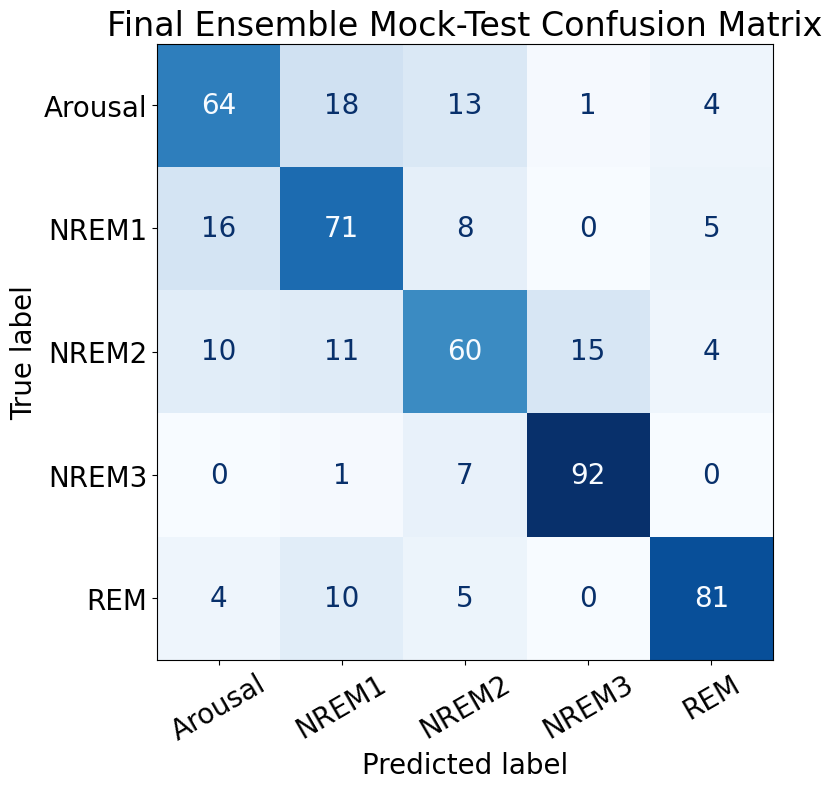

In [ ]:
### Final evaluation on the held-out mock-test set ###

# Obtain probabilities from each trained model
mock_et_probabilities = extra_trees_model.predict_proba(
    mocktest_data
)

mock_svm_probabilities = svm_model.predict_proba(
    mocktest_data
)

mock_xgb_probabilities = xgb_model.predict_proba(
    mocktest_data
)

# Chosen validation weights:
# 30% Extra Trees + 10% SVM + 60% XGBoost
mock_ensemble_probabilities = (
    0.30 * mock_et_probabilities
    + 0.10 * mock_svm_probabilities
    + 0.60 * mock_xgb_probabilities
)

mock_ensemble_predictions = np.argmax(
    mock_ensemble_probabilities,
    axis=1
)

# Confirm valid probabilities
print(
    "Probability row sums:",
    mock_ensemble_probabilities.sum(axis=1).min(),
    "to",
    mock_ensemble_probabilities.sum(axis=1).max()
)

# Accuracy
mock_accuracy = accuracy_score(
    mocktest_integer_labels,
    mock_ensemble_predictions
)

# Micro AUC
mock_one_hot = np.eye(5)[mocktest_integer_labels]

mock_fpr, mock_tpr, _ = roc_curve(
    mock_one_hot.ravel(),
    mock_ensemble_probabilities.ravel()
)

mock_auc = auc(
    mock_fpr,
    mock_tpr
)

# Arousal MCC
mock_true_arousal = (
    mocktest_integer_labels == 0
).astype(int)

mock_predicted_arousal = (
    mock_ensemble_predictions == 0
).astype(int)

mock_mcc = matthews_corrcoef(
    mock_true_arousal,
    mock_predicted_arousal
)

print(f"\nFinal mock-test accuracy:    {mock_accuracy:.4f}")
print(f"Final mock-test micro AUC:   {mock_auc:.4f}")
print(f"Final mock-test arousal MCC: {mock_mcc:.4f}")

print("\nFinal mock-test classification report:")
print(
    classification_report(
        mocktest_integer_labels,
        mock_ensemble_predictions,
        target_names=[
            stage_dict[i] for i in range(5)
        ],
        digits=4
    )
)

# Confusion matrix
mock_confusion = confusion_matrix(
    mocktest_integer_labels,
    mock_ensemble_predictions
)

mock_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=mock_confusion,
    display_labels=[
        stage_dict[i] for i in range(5)
    ]
)

fig, ax = plt.subplots(figsize=(10, 8))

mock_cm_display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Final Ensemble Mock-Test Confusion Matrix")
plt.xticks(rotation=30)
plt.show()

In [ ]:
### Compare every trained model on the mock-test set ###

def calculate_mock_metrics(probabilities):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    model_accuracy = accuracy_score(
        mocktest_integer_labels,
        predictions
    )

    model_fpr, model_tpr, _ = roc_curve(
        mock_one_hot.ravel(),
        probabilities.ravel()
    )

    model_auc = auc(
        model_fpr,
        model_tpr
    )

    model_mcc = matthews_corrcoef(
        mock_true_arousal,
        (predictions == 0).astype(int)
    )

    arousal_recall = recall_score(
        mocktest_integer_labels,
        predictions,
        average=None
    )[0]

    return (
        model_accuracy,
        model_auc,
        model_mcc,
        arousal_recall
    )


mock_model_results = []

model_probability_sets = {
    "Extra Trees": mock_et_probabilities,
    "RBF SVM": mock_svm_probabilities,
    "XGBoost": mock_xgb_probabilities,
    "30/10/60 Ensemble": mock_ensemble_probabilities
}

for model_name, probabilities in model_probability_sets.items():

    accuracy_value, auc_value, mcc_value, recall_value = (
        calculate_mock_metrics(probabilities)
    )

    mock_model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_value,
        "Micro AUC": auc_value,
        "Arousal MCC": mcc_value,
        "Arousal Recall": recall_value
    })

mock_model_results_df = pd.DataFrame(
    mock_model_results
)

print(
    mock_model_results_df
    .sort_values("Micro AUC", ascending=False)
    .to_string(index=False)
)

            Model  Accuracy  Micro AUC  Arousal MCC  Arousal Recall
30/10/60 Ensemble     0.736   0.947106     0.578431            0.64
          XGBoost     0.740   0.946537     0.584429            0.66
      Extra Trees     0.734   0.936411     0.546643            0.63
          RBF SVM     0.726   0.928557     0.561843            0.60


In [ ]:
### Five-fold cross-validation for XGBoost ###

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

five_fold_split = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_oof_probabilities = np.zeros(
    (len(train_data), 5),
    dtype=np.float64
)

fold_results = []

for fold_number, (fold_train_indices, fold_test_indices) in enumerate(
    five_fold_split.split(
        train_data,
        integer_train_labels
    ),
    start=1
):

    print(f"Training XGBoost fold {fold_number}/5...")

    fold_model = clone(xgb_model)

    fold_model.fit(
        train_data[fold_train_indices],
        integer_train_labels[fold_train_indices]
    )

    fold_probabilities = fold_model.predict_proba(
        train_data[fold_test_indices]
    )

    xgb_oof_probabilities[
        fold_test_indices
    ] = fold_probabilities

    fold_predictions = np.argmax(
        fold_probabilities,
        axis=1
    )

    fold_true_labels = integer_train_labels[
        fold_test_indices
    ]

    fold_accuracy = accuracy_score(
        fold_true_labels,
        fold_predictions
    )

    fold_one_hot = np.eye(5)[fold_true_labels]

    fold_fpr, fold_tpr, _ = roc_curve(
        fold_one_hot.ravel(),
        fold_probabilities.ravel()
    )

    fold_auc = auc(
        fold_fpr,
        fold_tpr
    )

    fold_mcc = matthews_corrcoef(
        (fold_true_labels == 0).astype(int),
        (fold_predictions == 0).astype(int)
    )

    fold_results.append({
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Micro AUC": fold_auc,
        "Arousal MCC": fold_mcc
    })


xgb_cv_results = pd.DataFrame(fold_results)

print("\nFive-fold results:")
print(xgb_cv_results.to_string(index=False))

print("\nMean cross-validation scores:")
print(
    xgb_cv_results[
        ["Accuracy", "Micro AUC", "Arousal MCC"]
    ].mean()
)

print("\nCross-validation score variation:")
print(
    xgb_cv_results[
        ["Accuracy", "Micro AUC", "Arousal MCC"]
    ].std()
)

Training XGBoost fold 1/5...
Training XGBoost fold 2/5...
Training XGBoost fold 3/5...
Training XGBoost fold 4/5...
Training XGBoost fold 5/5...

Five-fold results:
 Fold  Accuracy  Micro AUC  Arousal MCC
    1   0.76500   0.954861     0.684531
    2   0.76500   0.955047     0.684312
    3   0.75875   0.950449     0.659201
    4   0.75875   0.946589     0.692018
    5   0.76250   0.953418     0.668856

Mean cross-validation scores:
Accuracy       0.762000
Micro AUC      0.952073
Arousal MCC    0.677784
dtype: float64

Cross-validation score variation:
Accuracy       0.003137
Micro AUC      0.003576
Arousal MCC    0.013377
dtype: float64


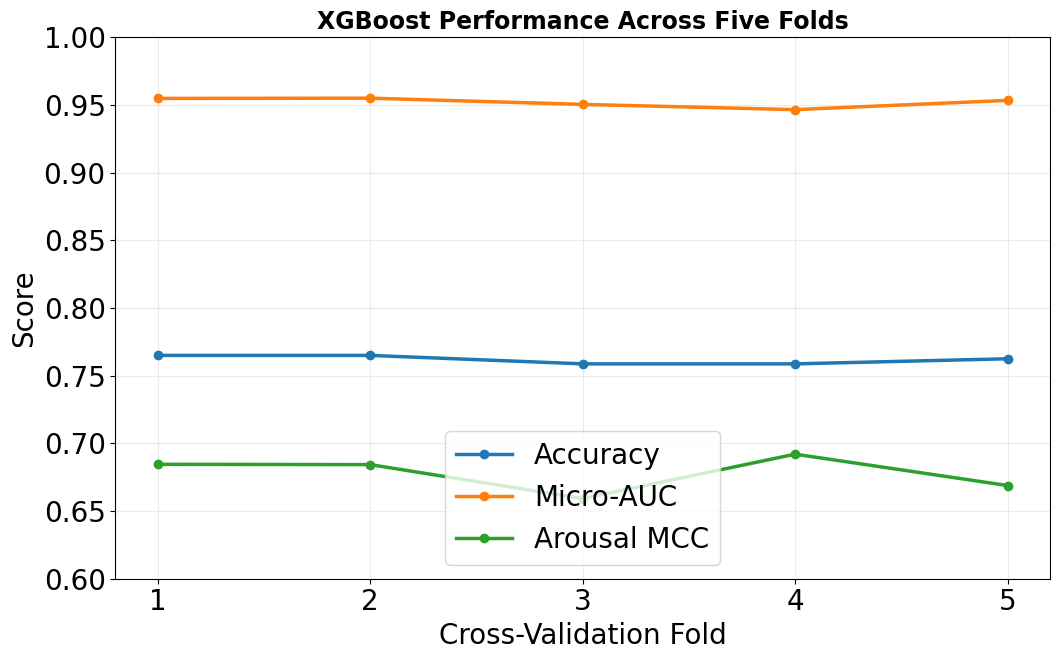

In [ ]:
plt.figure(figsize=(11, 7))

plt.plot(
    xgb_cv_results["Fold"],
    xgb_cv_results["Accuracy"],
    marker="o",
    linewidth=2.5,
    label="Accuracy"
)

plt.plot(
    xgb_cv_results["Fold"],
    xgb_cv_results["Micro AUC"],
    marker="o",
    linewidth=2.5,
    label="Micro-AUC"
)

plt.plot(
    xgb_cv_results["Fold"],
    xgb_cv_results["Arousal MCC"],
    marker="o",
    linewidth=2.5,
    label="Arousal MCC"
)

plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0.60, 1.00)
plt.xlabel("Cross-Validation Fold")
plt.ylabel("Score")

plt.title(
    "XGBoost Performance Across Five Folds",
    fontsize=17,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
### Tune one Arousal probability multiplier using OOF predictions ###

arousal_multiplier_results = []

for multiplier in np.linspace(0.60, 1.60, 101):

    adjusted_probabilities = (
        xgb_oof_probabilities.copy()
    )

    # Increase or decrease Arousal confidence
    adjusted_probabilities[:, 0] *= multiplier

    # Normalize each row so probabilities add to 1
    adjusted_probabilities /= (
        adjusted_probabilities.sum(
            axis=1,
            keepdims=True
        )
    )

    adjusted_predictions = np.argmax(
        adjusted_probabilities,
        axis=1
    )

    adjusted_accuracy = accuracy_score(
        integer_train_labels,
        adjusted_predictions
    )

    adjusted_one_hot = np.eye(5)[
        integer_train_labels
    ]

    adjusted_fpr, adjusted_tpr, _ = roc_curve(
        adjusted_one_hot.ravel(),
        adjusted_probabilities.ravel()
    )

    adjusted_auc = auc(
        adjusted_fpr,
        adjusted_tpr
    )

    adjusted_mcc = matthews_corrcoef(
        (integer_train_labels == 0).astype(int),
        (adjusted_predictions == 0).astype(int)
    )

    arousal_recall = recall_score(
        integer_train_labels,
        adjusted_predictions,
        average=None
    )[0]

    arousal_multiplier_results.append({
        "Multiplier": multiplier,
        "Accuracy": adjusted_accuracy,
        "Micro AUC": adjusted_auc,
        "Arousal MCC": adjusted_mcc,
        "Arousal Recall": arousal_recall
    })


arousal_multiplier_df = pd.DataFrame(
    arousal_multiplier_results
)

print("Baseline with no adjustment:")
print(
    arousal_multiplier_df[
        np.isclose(
            arousal_multiplier_df["Multiplier"],
            1.0
        )
    ].to_string(index=False)
)

print("\nBest multipliers for MCC:")
print(
    arousal_multiplier_df
    .sort_values(
        ["Arousal MCC", "Micro AUC"],
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

print("\nBest multipliers for accuracy:")
print(
    arousal_multiplier_df
    .sort_values(
        ["Accuracy", "Micro AUC"],
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

Baseline with no adjustment:
 Multiplier  Accuracy  Micro AUC  Arousal MCC  Arousal Recall
        1.0     0.762   0.952062     0.677187         0.75375

Best multipliers for MCC:
 Multiplier  Accuracy  Micro AUC  Arousal MCC  Arousal Recall
       1.18   0.76175   0.951901     0.679406         0.78000
       0.98   0.76225   0.952059     0.678403         0.75125
       1.19   0.76125   0.951885     0.678243         0.78000
       0.96   0.76175   0.952055     0.677780         0.74875
       1.00   0.76200   0.952062     0.677187         0.75375
       0.97   0.76175   0.952055     0.677159         0.74875
       0.65   0.76025   0.951137     0.677094         0.68250
       1.20   0.76125   0.951866     0.677083         0.78000
       1.01   0.76200   0.952060     0.676894         0.75500
       1.02   0.76200   0.952057     0.676894         0.75500

Best multipliers for accuracy:
 Multiplier  Accuracy  Micro AUC  Arousal MCC  Arousal Recall
       0.98   0.76225   0.952059     0.67840

In [ ]:
### Train final selected model on all labeled samples ###

from sklearn.base import clone

final_xgb_model = clone(xgb_model)

print(
    "Training final XGBoost model on:",
    train_data.shape
)

final_xgb_model.fit(
    train_data,
    integer_train_labels
)

print("Final XGBoost training complete.")

Training final XGBoost model on: (4000, 180)
Final XGBoost training complete.


In [ ]:
### Generate and validate final challenge submission ###

# Generate five class probabilities for all 1,000 test samples
final_test_probabilities = final_xgb_model.predict_proba(
    test_data
)

print(
    "Raw prediction shape:",
    final_test_probabilities.shape
)

# Create dataframe with explicit class columns
submission_with_ids = pd.DataFrame(
    final_test_probabilities,
    columns=[0, 1, 2, 3, 4]
)

# Attach the original sample numbers
submission_with_ids["sample_id"] = (
    test_order.astype(int)
)

# Guarantee order: 0.xz, 1.xz, ..., 999.xz
submission_with_ids = submission_with_ids.sort_values(
    by="sample_id"
).reset_index(drop=True)

# Remove ID because submission must have exactly five columns
final_submission = submission_with_ids.drop(
    columns=["sample_id"]
)

# Validate the dataframe
row_sums = final_submission.sum(axis=1)

print("\nFinal submission shape:", final_submission.shape)
print(
    "All values finite:",
    np.all(np.isfinite(final_submission.values))
)
print(
    "Minimum probability:",
    final_submission.values.min()
)
print(
    "Maximum probability:",
    final_submission.values.max()
)
print(
    "Smallest row sum:",
    row_sums.min()
)
print(
    "Largest row sum:",
    row_sums.max()
)

print("\nFirst five prediction rows:")
print(final_submission.head())

# Stop if the format is incorrect
assert final_submission.shape == (1000, 5)
assert np.all(np.isfinite(final_submission.values))
assert final_submission.values.min() >= 0
assert final_submission.values.max() <= 1
assert np.allclose(row_sums.values, 1.0, atol=1e-5)

# Save using XZ compression
submission_file = (
    "/content/Tejshree_Sleep_XGBoost_180Features.xz"
)

final_submission.to_pickle(
    submission_file,
    compression="xz"
)

# Reload the saved file to ensure it was written correctly
verified_submission = pd.read_pickle(
    submission_file,
    compression="xz"
)

assert verified_submission.shape == (1000, 5)
assert np.allclose(
    verified_submission.values,
    final_submission.values
)

print("\nSubmission file verified successfully.")
print(
    "File size:",
    f"{os.path.getsize(submission_file) / 1_000_000:.3f} MB"
)

files.download(submission_file)

Raw prediction shape: (1000, 5)

Final submission shape: (1000, 5)
All values finite: True
Minimum probability: 7.1455004e-05
Maximum probability: 0.9975777
Smallest row sum: 0.9999998807907104
Largest row sum: 1.0000001192092896

First five prediction rows:
          0         1         2         3         4
0  0.000158  0.000220  0.004862  0.994412  0.000349
1  0.459325  0.221740  0.289650  0.013674  0.015610
2  0.014914  0.713701  0.062813  0.000684  0.207887
3  0.008443  0.014735  0.937397  0.027004  0.012421
4  0.495991  0.328591  0.105296  0.026160  0.043963

Submission file verified successfully.
File size: 0.019 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#  ### Run every time you change set of parameters ###

# model = tf.keras.Sequential()

# """ Modify to your heart's and algorithm's content ^_^ """

# model.add(tf.keras.layers.Dense(64, activation=tf.nn.relu, input_shape=(train_data.shape[1],)))
# model.add(tf.keras.layers.Dense(64, activation=tf.nn.relu))
# # we should end with a softmax to ensure outputs behave like probabilities
# #(i.e. sum to 1)
# model.add(tf.keras.layers.Dense(5, activation=tf.nn.softmax))

# opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
# #Another potential optimizer
# #opt = tf.keras.optimizers.Adam(learning_rate=0.0005)
# model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# model.summary()

In [ ]:
# ### Run whenever you want to train and validate your model ###

# """
# EPOCHS (int) the number of times the optimization algorithm passes
# through the full dataset (calculating errors and derivatives) to update weights
# (One pass through the data is called an "epoch")
# """

# EPOCHS = 50

# for epoch in range(EPOCHS):
#     for signals, labels in training_set:
#         tr_loss, tr_accuracy = model.train_on_batch(signals, labels)
#     val_loss, val_accuracy = model.evaluate(val_data, val_labels)
#     print(('Epoch #%d\t Training Loss: %.2f\tTraining Accuracy: %.2f\t'
#          'Validation Loss: %.2f\tValidation Accuracy: %.2f')
#          % (epoch + 1, tr_loss, tr_accuracy,
#          val_loss, val_accuracy))

In [ ]:
# ### Run once after you have finished training your model ###

# test_pred = model.predict(test_data)
# test_output = np.ndarray(shape = (1000, 6))

# # """ Add column with file number """
# for i in range(1000):
#     test_output[i] = np.append(test_pred[i], test_order[i])
# test_dataframe = pd.DataFrame(test_output)

# """ Sort dataframe according to file number """
# sorted_test_dataframe = test_dataframe.sort_values(by=[5])

# """ Drop file number column """
# processed_test_dataframe = sorted_test_dataframe.drop(sorted_test_dataframe.columns[5], axis=1)
# ### Run once after you have finished training your model ###

# test_pred = model.predict(test_data)
# test_output = np.ndarray(shape = (1000, 6))

# # """ Add column with file number """
# for i in range(1000):
#     test_output[i] = np.append(test_pred[i], test_order[i])
# test_dataframe = pd.DataFrame(test_output)

# """ Sort dataframe according to file number """
# sorted_test_dataframe = test_dataframe.sort_values(by=[5])

# """ Drop file number column """
# processed_test_dataframe = sorted_test_dataframe.drop(sorted_test_dataframe.columns[5], axis=1)

# print(test_dataframe.head(), '\n\n', sorted_test_dataframe.head(), '\n\n', processed_test_dataframe.head())

# file = 'SquashisGreatL.xz'
# processed_test_dataframe.to_pickle(file)
# test_dataframe = pd.DataFrame(test_output)
# os.listdir('.')
# files.download(file)

# print(test_dataframe.head(), '\n\n', sorted_test_dataframe.head(), '\n\n', processed_test_dataframe.head())

# file = 'SquashisGreatL.xz'
# processed_test_dataframe.to_pickle(file)
# test_dataframe = pd.DataFrame(test_output)
# os.listdir('.')
# files.download(file)


## Submitting Your Model

After training your classifier, run it on the test data to generate your predictions. Each class for a test sample should have an associated probability (between 0 and 1). Below are the parameters for the prediction format and export:

- Your predictions should be in a pandas dataframe with 5 columns (classes) and 1000 rows (samples). Note that your predictions must follow the original test sample order (0.xz, 1.xz, 2.xz, ...). You only need to worry about this if you shuffled the test samples or stored the samples in an unordered data structure (dictionaries and sets). If this is the case, you should 1) add a separate column in your pandas dataframe with the file number for each sample; 2) sort the dataframe using this column; and 3) drop the column. These steps have been noted in the code below.
- The predictions dataframe should be exported as an .xz file using dataframe.to_pickle() followed by files.download().

Example code of the prediction format and export is presented in the cell block below.

Your model will be evaluated on Area Under the ROC Curve (ROCAUC), Matthews Correlation Coefficient (MCC) and creativity. There will be a "winning" group for each of these categories.

If you are finished early, consider trying other ML algorithms and/or implementing multiple feature extraction methods. You can also help other groups if you finish early.

## How Your Model Will Be Evaluated

- **Area Under the ROC Curve (AUCROC)**: The receiver operating characteristic (ROC) curve plots the true positive rate (sensitivity/recall) against the false positive rate (fall-out) at many decision threshold settings. The area under the curve (AUC) measures discrimination, the classifier's ability to correctly identify samples from the "positive" and "negative" cases. Intuitively, AUC is the probability that a randomly chosen "positive" sample will be labeled as "more positive" than a randomly chosen "negative" sample. In the case of a multi-class ROC curve, each class is considered separately before taking the weighted average of all the class results. Simply put, the class under consideration is labeled as "positive" while all other classes are labeled as "negative." Below is the multi-class ROC curve for the example classifier. The AUCROC score should be between 0 and 1, in which 0.5 is random classification and 1 is perfect classification.

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/MultiClassRocCurve_exampleClassifier.png?raw=true" width="600" height="500">

- **Matthews Correlation Coefficient (MCC)**: The MCC measures the quality of binary classifications, irrespective of the class sizes. Importantly, it is typically regarded as a balanced measure since it considers all values in the 2x2 contingency table (TP, FP, TN, FN). For this challenge, the binary classes will be "Arousal" (Arousal) and "Nonarousal" (NREM1, NREM2, NREM3, REM). The MCC score should be between -1 and 1, in which 0 is random classification and 1 is perfect classification.

 ![alt text](https://wikimedia.org/api/rest_v1/media/math/render/svg/5caa90fc15105b74b59a30bbc9cc2e5bd43a13b7)

Using these metrics, the example classifier has the following scores on test data:
- AUCROC: 0.727
- MCC: 0.163
- Creativity: ( ͡° ͜ʖ ͡°)

Below is the code used to calculate the AUCROC and MCC metrics when evaluating your classifier.

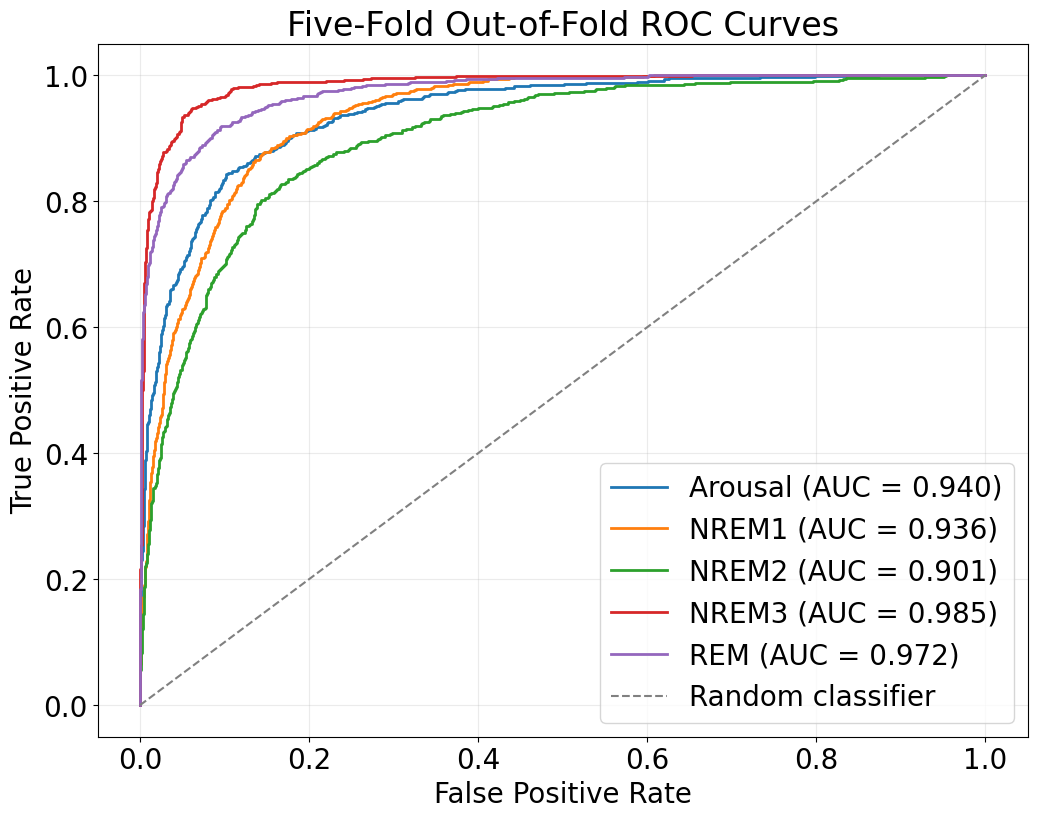

Five-fold OOF accuracy:    0.7620
Five-fold OOF micro AUC:   0.9521
Five-fold OOF arousal MCC: 0.6772


In [ ]:
### Evaluate the selected XGBoost approach using out-of-fold predictions ###

evaluation_probabilities = xgb_oof_probabilities
evaluation_labels = integer_train_labels

evaluation_predictions = np.argmax(
    evaluation_probabilities,
    axis=1
)

evaluation_labels_one_hot = np.eye(5)[
    evaluation_labels
]

# ---------------------------------------------------------
# Plot one-versus-rest ROC curve for every sleep stage
# ---------------------------------------------------------

class_auc_scores = {}

plt.figure(figsize=(12, 9))

for class_number in range(5):

    class_fpr, class_tpr, _ = metrics.roc_curve(
        evaluation_labels_one_hot[:, class_number],
        evaluation_probabilities[:, class_number]
    )

    class_auc = metrics.auc(
        class_fpr,
        class_tpr
    )

    class_auc_scores[class_number] = class_auc

    plt.plot(
        class_fpr,
        class_tpr,
        linewidth=2,
        label=(
            f"{stage_dict[class_number]} "
            f"(AUC = {class_auc:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Five-Fold Out-of-Fold ROC Curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ---------------------------------------------------------
# Calculate the challenge-style aggregate micro AUC
# ---------------------------------------------------------

aggregate_fpr, aggregate_tpr, _ = metrics.roc_curve(
    evaluation_labels_one_hot.ravel(),
    evaluation_probabilities.ravel()
)

aggregate_auc = metrics.auc(
    aggregate_fpr,
    aggregate_tpr
)

# ---------------------------------------------------------
# Calculate Arousal versus Non-arousal MCC
# ---------------------------------------------------------

true_arousal_labels = (
    evaluation_labels == 0
).astype(int)

predicted_arousal_labels = (
    evaluation_predictions == 0
).astype(int)

final_mcc = metrics.matthews_corrcoef(
    true_arousal_labels,
    predicted_arousal_labels
)

final_accuracy = metrics.accuracy_score(
    evaluation_labels,
    evaluation_predictions
)

print(f"Five-fold OOF accuracy:    {final_accuracy:.4f}")
print(f"Five-fold OOF micro AUC:   {aggregate_auc:.4f}")
print(f"Five-fold OOF arousal MCC: {final_mcc:.4f}")